# LIBRARIES

In [32]:
import math
import random
from queue import Queue, PriorityQueue
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CLASSES

## MEASURES

In [12]:
class Measure:
    def __init__(self,Narr,Ndep,NAveraegUser,OldTimeEvent,AverageDelay):
        self.arr = Narr
        self.dep = Ndep
        self.ut = NAveraegUser
        self.oldT = OldTimeEvent
        self.delay = AverageDelay
        self.waiting_delay = 0  # Average waiting time in queue
        self.waiting_delays = []  # List of individual waiting delays
        self.buffer_occ = 0  # Average buffer occupancy (number of customers in queue)
        self.losses = 0  # Number of customers lost (rejected)
        self.busy_time = 0  # Cumulative busy time of the server

## CLIENT

In [13]:
class Client:
    client_id_counter = 0  # Class variable to generate unique IDs
    
    def __init__(self, type, arrival_time):
        self.type = type
        self.arrival_time = arrival_time
        self.service_start_time = None  # When the service begins
        self.client_id = Client.client_id_counter  # Unique identifier
        Client.client_id_counter += 1

## SERVER

In [29]:
class Server(object):

    # constructor
    def __init__(self, server_id, service_rate=None):
        self.id = server_id
        # whether the server is idle or not
        self.idle = True
        self.busy_since = None  # Track when server became busy
        self.busy_time = 0.0    # Cumulative busy time (per-server)
        self.served = 0         # Number of completed jobs (per-server)
        # per-server service rate μ (customers per time unit)
        # if None, it defaults to the homogeneous case (μ = 1/SERVICE)
        self.mu = service_rate if service_rate is not None else (1.0 / SERVICE)

# CONSTANT

In [33]:

SERVICE = 10.0  # Average service time per customer (SERVICE = 1/μ where μ is service rate)

# ARRIVALS: Mean inter-arrival times (NOT arrival rates!)
# ARRIVALS = 1/λ where λ is the arrival rate
# All scenarios are stable for M/M/2, showing clear benefit of 2 servers
# M/M/1 ρ = [0.40, 0.50, 0.67, 0.83, 0.91, 1.11]  → stable up to 11, fully unstable at 9
# M/M/2 ρ = [0.20, 0.25, 0.33, 0.42, 0.45, 0.55]  → all comfortably stable
ARRIVALS = [25, 20, 15, 12, 11, 9]

# Load factor ρ = λ/μ = (1/arrival) / (1/SERVICE) = SERVICE/arrival
# ρ represents system utilization: stable when ρ < 1
#LOAD = [SERVICE/arrival for arrival in ARRIVALS] --> mai usato perché non serve a nulla, basta calcolare ρ direttamente quando serve

TYPE1 = 1 

#NUM_SERVERS = 1   Number of servers in the system (change this to simulate M/M/N)

BUFFER_SIZE = float('inf')  # Maximum buffer size for finite capacity queue

SIM_TIME = 500000

users = 0 # Number of users currently in the system (in service + in queue)
servers = []  # Pool of servers - will be initialized before each simulation

MMn = []


# FUNCTIONS

In [34]:
def make_service_time_sampler(mean_service_time, dist="exponential", rng=None, **params):
    """Create a callable that samples i.i.d. service times for M/G/1-style experiments.

    Parameters
    ----------
    mean_service_time : float
        Target mean service time E[S].
    dist : str
        Distribution name. Supported: exponential, deterministic, erlang, uniform, lognormal, hyperexponential.
    rng : random.Random-like or module (optional)
        Source of randomness. Defaults to Python's `random` module.
    params : dict
        Distribution-specific parameters.

    Notes
    -----
    All distributions are parameterized to (approximately) match the provided mean service time,
    so comparisons isolate the effect of *variability* (not mean).
    """
    if mean_service_time <= 0:
        raise ValueError("mean_service_time must be > 0")
    if rng is None:
        rng = random
    name = (dist or "exponential").strip().lower()
    
    if name in {"exp", "exponential", "mm1"}:
        rate = 1.0 / mean_service_time
        return lambda: rng.expovariate(rate)
    
    if name in {"det", "deterministic", "constant"}:
        return lambda: mean_service_time
    
    if name in {"erlang", "gamma", "gamma_k"}:
        k = int(params.get("k", 2))
        if k <= 0:
            raise ValueError("Erlang/Gamma requires k >= 1")
        # Gamma(shape=k, scale=mean/k) => mean = k * scale = mean_service_time
        scale = mean_service_time / k
        return lambda: rng.gammavariate(k, scale)
    
    if name in {"uniform", "uni"}:
        # Uniform around the mean: [m(1-s), m(1+s)]
        spread = float(params.get("spread", 0.5))
        if spread < 0:
            raise ValueError("uniform spread must be >= 0")
        a = mean_service_time * (1.0 - spread)
        b = mean_service_time * (1.0 + spread)
        if b <= 0:
            raise ValueError("uniform parameters lead to non-positive support")
        a = max(0.0, a)
        return lambda: rng.uniform(a, b)
    
    if name in {"lognormal", "lognorm"}:
        # Choose underlying normal params so that E[S] = mean_service_time
        sigma = float(params.get("sigma", 1.0))
        if sigma < 0:
            raise ValueError("lognormal sigma must be >= 0")
        mu_ln = math.log(mean_service_time) - 0.5 * (sigma ** 2)
        return lambda: rng.lognormvariate(mu_ln, sigma)
    
    if name in {"hyperexp", "hyperexponential", "h2"}:
        # Two-phase hyperexponential: with prob p use Exp(mu1), else Exp(mu2)
        # You can pass (mu1, mu2, p) explicitly, otherwise we construct a pair matching the mean.
        p = float(params.get("p", 0.5))
        if not (0.0 < p < 1.0):
            raise ValueError("hyperexponential requires 0 < p < 1")
        mu1 = params.get("mu1", None)
        mu2 = params.get("mu2", None)
        if mu1 is None or mu2 is None:
            # Construct rates to match mean using a 'fast_factor' for mu1, solve mu2 from mean constraint.
            fast_factor = float(params.get("fast_factor", 5.0))
            if fast_factor <= 1.0:
                raise ValueError("fast_factor must be > 1 for a meaningful hyperexponential")
            mu1 = fast_factor / mean_service_time
            remaining_mean = mean_service_time - p * (1.0 / mu1)
            if remaining_mean <= 0:
                raise ValueError("hyperexponential construction failed; adjust p/fast_factor")
            mu2 = (1.0 - p) / remaining_mean
        mu1 = float(mu1)
        mu2 = float(mu2)
        if mu1 <= 0 or mu2 <= 0:
            raise ValueError("hyperexponential requires mu1, mu2 > 0")
        return lambda: (rng.expovariate(mu1) if rng.random() < p else rng.expovariate(mu2))
    
    raise ValueError(f"Unknown service-time distribution: {dist!r}")


def summarize_service_distribution(mean_service_time, dist="exponential", sample_size=50000, seed=12345, **params):
    """Empirically summarize a service distribution (mean, variance, SCV) without affecting global RNG."""
    rng = random.Random(seed)
    sampler = make_service_time_sampler(mean_service_time, dist=dist, rng=rng, **params)
    samples = [sampler() for _ in range(int(sample_size))]
    mean = float(np.mean(samples))
    var = float(np.var(samples))
    scv = var / (mean ** 2) if mean > 0 else float('nan')  # squared coefficient of variation
    return {"mean": mean, "var": var, "scv": scv}

## ARRIVAL

In [35]:
def arrival(data, time, FES, queue, arr_time, event_counter=0, service_sampler=None):
    global users
    
    #print("Arrival no. ",data.arr+1," at time ",time," with ",users," users" )
    
    # cumulate statistics
    num_servers = len(servers)
    data.ut += users*(time-data.oldT)
    data.buffer_occ += max(users - num_servers, 0) * (time - data.oldT)  # queue length
    data.busy_time += min(users, num_servers) * (time - data.oldT)  # Busy time: cumulate based on number of occupied servers
    data.oldT = time

    # sample the time until the next event
    inter_arrival = random.expovariate(lambd=1.0/arr_time)
        
    # schedule the next arrival
    event_counter += 1
    FES.put((time + inter_arrival, event_counter, "arrival"))

    # Check if buffer is full - if so, customer is lost
    if users >= BUFFER_SIZE:
        data.losses += 1
        return
    
    # Otherwise, accept the customer
    data.arr += 1
    users += 1
    
    # create a record for the client
    client = Client(TYPE1, time)

    # insert the record in the queue
    queue.append(client)

    # if there's an idle server, start the service immediately
    idle_server = next((server for server in servers if server.idle), None)
    if idle_server:
        # Mark the service start time for this client
        client.service_start_time = time
        idle_server.idle = False
        idle_server.busy_since = time
        
        # sample the service time (defaults to exponential for backward compatibility)
        if service_sampler is None:
            service_time = random.expovariate(1.0 / SERVICE)
        else:
            service_time = service_sampler()

        # schedule when the client will finish the server (use client_id instead of object)
        event_counter += 1
        FES.put((time + service_time, event_counter, "departure", idle_server.id, client.client_id))

## DEPARTURES

In [36]:
def departure(data, time, FES, queue, server_id, client_id=None, event_counter=0, service_sampler=None):
    global users

    #print("Departure no. ",data.dep+1," at time ",time," with ",users," users" )
        
    # cumulate statistics
    num_servers = len(servers)
    data.dep += 1
    data.ut += users*(time-data.oldT)
    data.buffer_occ += max(users - num_servers, 0) * (time - data.oldT)  # queue length
    data.busy_time += min(users, num_servers) * (time - data.oldT)  # Busy time: cumulate based on number of occupied servers
    data.oldT = time
    
    # Find and remove client by ID from queue
    if client_id is None:
        # Backward compatibility: pop first client
        client = queue.pop(0)
    else:
        # Find the client with matching ID and remove it
        client = None
        for c in queue:
            if c.client_id == client_id:
                client = c
                queue.remove(c)
                break
        if client is None:
            # If client not found, something went wrong - use first client
            client = queue.pop(0) if queue else None
            if client is None:
                return  # No client to serve
    
    # do whatever we need to do when clients go away
    
    # Calculate total delay (system time)
    data.delay += (time-client.arrival_time)
    
    # Calculate waiting delay (time in queue before service)
    if client.service_start_time is not None:
        waiting_delay = client.service_start_time - client.arrival_time
        data.waiting_delay += waiting_delay
        data.waiting_delays.append(waiting_delay)
    
    users -= 1
    
    # Mark this server as idle + update per-server busy stats
    server = servers[server_id]
    if server.busy_since is not None:
        server.busy_time += (time - server.busy_since)
    server.served += 1
    server.idle = True
    server.busy_since = None
    
    # see whether there are more clients in the queue
    next_client = next((c for c in queue if c.service_start_time is None), None)
    if next_client is not None:
        # Find an idle server to serve the next client
        idle_server = next((server for server in servers if server.idle), None)
        if idle_server:
            # Mark the service start time for the next client
            next_client.service_start_time = time
            idle_server.idle = False
            idle_server.busy_since = time
            
            # sample the service time (defaults to exponential for backward compatibility)
            if service_sampler is None:
                service_time = random.expovariate(1.0 / SERVICE)
            else:
                service_time = service_sampler()

            # schedule when the client will finish the server (use client_id instead of object)
            event_counter += 1
            FES.put((time + service_time, event_counter, "departure", idle_server.id, next_client.client_id))

## CONFIDENCE INTERVALS

In [18]:
def confidence_interval(data, confidence=0.95):
    
    n = len(data)
    mean = np.mean(data)
    std_err = st.sem(data)
    h = std_err * st.t.ppf((1 + confidence) / 2, n - 1)

    return mean, mean - h, mean + h

## REPORT

In [19]:
def report(all_results, arrivals, service):
    """
    Print summary statistics for all scenarios
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    """
    for arrival_scenario in arrivals:
        results = all_results[arrival_scenario]
        
        print("=" * 60)
        print(f"RESULTS FROM 25 SIMULATIONS - ARRIVAL = {arrival_scenario}")
        print("=" * 60)
        
        print("\nNUMBER OF ARRIVALS:")
        mean, lower, upper = confidence_interval(results['arrivals'])
        print(f"  Mean: {mean:.2f}, CI[95%]: [{lower:.2f}, {upper:.2f}]")
        
        print("\nNUMBER OF DEPARTURES:")
        mean, lower, upper = confidence_interval(results['departures'])
        print(f"  Mean: {mean:.2f}, CI[95%]: [{lower:.2f}, {upper:.2f}]")
        
        print("\nAVERAGE NUMBER OF USERS IN SYSTEM:")
        mean, lower, upper = confidence_interval(results['avg_users'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE DELAY (total system time per customer):")
        mean, lower, upper = confidence_interval(results['avg_delay'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE WAITING DELAY (time in queue per customer):")
        mean, lower, upper = confidence_interval(results['avg_waiting_delay'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nAVERAGE BUFFER OCCUPANCY (number of customers in queue):")
        mean, lower, upper = confidence_interval(results['avg_buffer_occupancy'])
        print(f"  Mean: {mean:.4f}, CI[95%]: [{lower:.4f}, {upper:.4f}]")
        
        print("\nLOSS PROBABILITY (probability that arriving customer is blocked):")
        mean, lower, upper = confidence_interval(results['loss_probability'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nSERVER UTILIZATION (busy time):")
        mean, lower, upper = confidence_interval(results['server_utilization'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nARRIVAL RATE:")
        mean, lower, upper = confidence_interval(results['arrival_rate'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print("\nDEPARTURE RATE:")
        mean, lower, upper = confidence_interval(results['departure_rate'])
        print(f"  Mean: {mean:.6f}, CI[95%]: [{lower:.6f}, {upper:.6f}]")
        
        print(f"\nLOAD FACTOR (λ/μ) = SERVICE/ARRIVAL = {service/arrival_scenario:.4f}")
        
        print()


## PLOT

In [20]:
def plot_results(all_results, arrivals, service):
    """
    Plot distribution of queuing delays for all scenarios
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    """
    n_scenarios = len(arrivals)
    n_cols = min(3, n_scenarios)
    n_rows = (n_scenarios + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    fig.suptitle('Distribution of Queuing Delays (Waiting Time in Queue)', fontsize=16, fontweight='bold')

    axes = axes.flatten() if n_scenarios > 1 else [axes]

    for idx, arrival_scenario in enumerate(arrivals):
        results = all_results[arrival_scenario]
        waiting_delays = results['waiting_delays']
        
        ax = axes[idx]
        
        # Plot histogram and KDE
        ax.hist(waiting_delays, bins=100, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram')
        
        # Add KDE
        if len(waiting_delays) > 1:
            from scipy.stats import gaussian_kde
            try:
                kde = gaussian_kde(waiting_delays)
                x_range = np.linspace(min(waiting_delays), max(waiting_delays), 200)
                ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            except np.linalg.LinAlgError:
                pass # Ignore if KDE fails (e.g. all values exactly 0)
        
        # Add mean and median lines
        mean_delay = np.mean(waiting_delays) if waiting_delays else 0
        median_delay = np.median(waiting_delays) if waiting_delays else 0
        ax.axvline(mean_delay, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_delay:.2f}')
        ax.axvline(median_delay, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_delay:.2f}')
        
        # Add statistics
        std_delay = np.std(waiting_delays) if waiting_delays else 0
        min_delay = np.min(waiting_delays) if waiting_delays else 0
        max_delay = np.max(waiting_delays) if waiting_delays else 0
        
        stats_text = f"N = {len(waiting_delays)}\nMean = {mean_delay:.2f}\nStd = {std_delay:.2f}\nMin = {min_delay:.2f}\nMax = {max_delay:.2f}\nLoad = {service/arrival_scenario:.4f}"
        ax.text(0.98, 0.88, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Queuing Delay (time units)', fontsize=10)
        ax.set_ylabel('Probability Density', fontsize=10)
        ax.set_title(f'ARRIVAL = {arrival_scenario} (ρ = {service/arrival_scenario:.4f})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Hide any unused axes
    for idx_to_hide in range(n_scenarios, len(axes)):
        axes[idx_to_hide].set_visible(False)

    # Create unified legend on the right side
    hist_patch = plt.Rectangle((0,0),1,1, fc='skyblue', edgecolor='black', alpha=0.6)
    kde_line = plt.Line2D([0], [0], color='r', linewidth=2)
    mean_line = plt.Line2D([0], [0], color='green', linestyle='--', linewidth=2)
    median_line = plt.Line2D([0], [0], color='orange', linestyle='--', linewidth=2)

    fig.legend([hist_patch, kde_line, mean_line, median_line], 
               ['Histogram', 'KDE', 'Mean', 'Median'],
               loc='center left', ncol=1, fontsize=11, bbox_to_anchor=(1.02, 0.5), frameon=True)

    plt.tight_layout()
    plt.show()


## PERFORMANCE METRICS

In [21]:
def plot_performance_metrics(all_results, arrivals, service):
    """
    Plot variation of performance metrics as a function of arrival rates
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    """
    # Extract metrics for each arrival scenario
    arrival_loads = [service / arr for arr in arrivals]  # Calculate load factor ρ
    
    metrics = {
        'avg_users': [],
        'avg_delay': [],
        'avg_waiting_delay': [],
        'avg_buffer_occupancy': [],
        'server_utilization': [],
        'loss_probability': []
    }
    
    # Collect mean values for each metric
    for idx, arrival_scenario in enumerate(arrivals):
        results = all_results[arrival_scenario]
        avg_u = np.mean(results['avg_users'])
        metrics['avg_users'].append(avg_u)
        metrics['avg_delay'].append(np.mean(results['avg_delay']))
        metrics['avg_waiting_delay'].append(np.mean(results['avg_waiting_delay']))
        metrics['avg_buffer_occupancy'].append(np.mean(results['avg_buffer_occupancy']))
        metrics['server_utilization'].append(np.mean(results['server_utilization']))
        metrics['loss_probability'].append(np.mean(results['loss_probability']))
        
        # Debug: print values for each scenario
        load_factor = arrival_loads[idx]
        print(f"Load factor ρ = {load_factor:.4f} (Arrival={arrival_scenario}): Avg Users = {avg_u:.4f}")
    
    # Create figure with 6 subplots
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Performance Metrics Variation with Load Factor (ρ)', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    # Plot 1: Average Users in System (logarithmic scale)
    axes[0].plot(arrival_loads, metrics['avg_users'], 'o-', linewidth=2, markersize=8, color='#1f77b4')
    axes[0].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Number of Users (log scale)', fontsize=11, fontweight='bold')
    axes[0].set_title('Average Number of Users in System (Log Scale)', fontsize=12, fontweight='bold')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3, which='both')
    
    # Plot 2: Average Delay (System Time) (logarithmic scale)
    axes[1].plot(arrival_loads, metrics['avg_delay'], 'o-', linewidth=2, markersize=8, color='#ff7f0e')
    axes[1].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Average Delay (time units, log scale)', fontsize=11, fontweight='bold')
    axes[1].set_title('Average System Delay (W) - Log Scale', fontsize=12, fontweight='bold')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3, which='both')
    
    # Plot 3: Average Waiting Delay (Queue Time) (logarithmic scale)
    axes[2].plot(arrival_loads, metrics['avg_waiting_delay'], 'o-', linewidth=2, markersize=8, color='#2ca02c')
    axes[2].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Average Waiting Delay (time units, log scale)', fontsize=11, fontweight='bold')
    axes[2].set_title('Average Queuing Delay (Wq) - Log Scale', fontsize=12, fontweight='bold')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3, which='both')
    
    # Plot 4: Average Buffer Occupancy (logarithmic scale)
    axes[3].plot(arrival_loads, metrics['avg_buffer_occupancy'], 'o-', linewidth=2, markersize=8, color='#d62728')
    axes[3].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[3].set_ylabel('Queue Length (log scale)', fontsize=11, fontweight='bold')
    axes[3].set_title('Average Buffer Occupancy (Lq) - Log Scale', fontsize=12, fontweight='bold')
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3, which='both')
    
    # Plot 5: Server Utilization
    axes[4].plot(arrival_loads, metrics['server_utilization'], 'o-', linewidth=2, markersize=8, color='#9467bd')
    axes[4].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[4].set_ylabel('Utilization Factor', fontsize=11, fontweight='bold')
    axes[4].set_title('Server Utilization (ρ)', fontsize=12, fontweight='bold')
    axes[4].axhline(y=1.0, color='r', linestyle='--', linewidth=1.5, alpha=0.5, label='Stability Limit (ρ=1)')
    axes[4].grid(True, alpha=0.3)
    axes[4].legend(fontsize=9)
    
    # Plot 6: Loss Probability
    axes[5].plot(arrival_loads, metrics['loss_probability'], 'o-', linewidth=2, markersize=8, color='#8c564b')
    axes[5].set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
    axes[5].set_ylabel('Loss Probability', fontsize=11, fontweight='bold')
    axes[5].set_title('Probability of Packet Loss', fontsize=12, fontweight='bold')
    axes[5].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()




## CONFIDENCE INTERVALS VISUALIZATION

In [22]:
def plot_confidence_intervals(all_results, arrivals, service, confidence=0.95):
    """
    Plot confidence intervals for all performance metrics
    
    Parameters:
    - all_results: dictionary containing results from get_results()
    - arrivals: list of arrival rates scenarios (ARRIVALS constant)
    - service: average service time (SERVICE constant)
    - confidence: confidence level (default 0.95 for 95% CI)
    """
    # Extract metrics for each arrival scenario
    arrival_loads = [service / arr for arr in arrivals]  # Calculate load factor ρ
    
    metrics_data = {
        'avg_users': {'means': [], 'lower': [], 'upper': [], 'label': 'Avg Users (Log Scale)'},
        'avg_delay': {'means': [], 'lower': [], 'upper': [], 'label': 'Avg System Delay (Log Scale)'},
        'avg_waiting_delay': {'means': [], 'lower': [], 'upper': [], 'label': 'Avg Queuing Delay (Log Scale)'},
        'avg_buffer_occupancy': {'means': [], 'lower': [], 'upper': [], 'label': 'Avg Buffer Occupancy (Log Scale)'},
        'server_utilization': {'means': [], 'lower': [], 'upper': [], 'label': 'Server Utilization'},
        'loss_probability': {'means': [], 'lower': [], 'upper': [], 'label': 'Loss Probability'}
    }
    
    # Calculate CI for each metric and each arrival scenario
    for arrival_scenario in arrivals:
        results = all_results[arrival_scenario]
        
        for metric_key in metrics_data.keys():
            data = results[metric_key]
            mean, lower, upper = confidence_interval(data, confidence=confidence)
            metrics_data[metric_key]['means'].append(mean)
            metrics_data[metric_key]['lower'].append(mean - lower)  # lower error
            metrics_data[metric_key]['upper'].append(upper - mean)  # upper error
    
    # Create figure with 6 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Performance Metrics with {int(confidence*100)}% Confidence Intervals', 
                 fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    metrics_list = ['avg_users', 'avg_delay', 'avg_waiting_delay', 'avg_buffer_occupancy', 
                   'server_utilization', 'loss_probability']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    use_log = [True, True, True, True, False, False]
    
    for idx, (metric_key, color, log_scale) in enumerate(zip(metrics_list, colors, use_log)):
        ax = axes[idx]
        metric = metrics_data[metric_key]
        
        # Plot with error bars
        ax.errorbar(arrival_loads, metric['means'], 
                   yerr=[metric['lower'], metric['upper']], 
                   fmt='o-', linewidth=2, markersize=8, capsize=5, capthick=2,
                   color=color, ecolor=color, alpha=0.7, label='95% CI')
        
        ax.set_xlabel('Load Factor (ρ = λ/μ)', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric['label'], fontsize=11, fontweight='bold')
        ax.set_title(metric['label'].replace(' (Log Scale)', ''), fontsize=12, fontweight='bold')
        
        if log_scale:
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3, which='both')
        else:
            ax.grid(True, alpha=0.3)
        
        # Add stability limit line if it's server utilization
        if metric_key == 'server_utilization':
            ax.axhline(y=1.0, color='r', linestyle='--', linewidth=1.5, alpha=0.5, 
                      label='Stability Limit (ρ=1)')
            ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*90}")
    print(f"CONFIDENCE INTERVALS SUMMARY ({int(confidence*100)}% Confidence Level)")
    print(f"{'='*90}\n")
    
    for arrival_scenario, load in zip(arrivals, arrival_loads):
        print(f"Load Factor ρ = {load:.4f} (Arrival = {arrival_scenario})")
        idx = arrivals.index(arrival_scenario)
        for metric_key in metrics_list:
            metric = metrics_data[metric_key]
            mean = metric['means'][idx]
            lower_err = metric['lower'][idx]
            upper_err = metric['upper'][idx]
            interval_width = lower_err + upper_err
            ratio = interval_width / mean if mean > 0 else float('inf')
            print(f"  {metric_key:25s}: {mean:12.4f} [{mean-lower_err:12.4f}, {mean+upper_err:12.4f}]  Ratio: {ratio:10.4f}")
        print()


## GET_RESULT

In [37]:
def get_results(service_time, arrivals, num_servers, buffer_size, sim_time, num_simulations=25,
                service_dist="exponential", service_params=None):
    """
    Execute M/G/n queue simulations (Event Scheduling) with customizable service-time distribution.
    
    Parameters:
    - service_time: mean service time E[S] (SERVICE constant)
    - arrivals: list of mean inter-arrival times to simulate (ARRIVALS constant)
    - num_servers: number of servers (NUM_SERVERS constant)
    - buffer_size: maximum buffer size (BUFFER_SIZE constant)
    - sim_time: simulation duration (SIM_TIME constant)
    - num_simulations: number of simulations per scenario (default=25)
    - service_dist: service-time distribution name (default: "exponential" -> M/M/n)
    - service_params: optional dict of parameters for the chosen distribution
    
    Returns:
    - all_results: dictionary containing results for each arrival scenario
    """
    global users, servers, MMn, BUFFER_SIZE, SERVICE
    
    BUFFER_SIZE = buffer_size
    SERVICE = service_time  # keep global consistent with the requested mean service time
    service_params = service_params or {}
    
    all_results = {}
    
    for arrival_scenario in arrivals:
        results = {
            'arrivals': [],
            'departures': [],
            'avg_users': [],
            'avg_delay': [],
            'avg_waiting_delay': [],
            'avg_buffer_occupancy': [],
            'loss_probability': [],
            'server_utilization': [],
            'arrival_rate': [],
            'departure_rate': [],
            'waiting_delays': []
        }
        
        for sim in range(num_simulations):
            # Reset random seed for reproducibility
            random.seed(42 + sim)
            
            # Create per-simulation service-time sampler (uses the same RNG seed as the sim)
            service_sampler = make_service_time_sampler(service_time, dist=service_dist, rng=random, **service_params)
            
            # Reset global variables for this simulation
            users = 0
            servers = [Server(i) for i in range(num_servers)]
            data = Measure(0, 0, 0, 0, 0)
            MMn = []
            Client.client_id_counter = 0  # RESET: crucial for tracking clients across scenarios
            
            # the simulation time 
            time = 0
            
            # the list of events in the form: (time, counter, type, server_id, client)
            FES = PriorityQueue()
            
            # Counter to break ties in event ordering (prevents comparison of non-comparable objects)
            event_counter = 0
            
            # schedule the first arrival at t=0
            FES.put((0, event_counter, "arrival"))
            event_counter += 1
            
            # Track total arrival attempts for loss probability calculation
            total_arrivals_attempted = 0
        
            
            # simulate until the simulated time reaches a constant
            while time < sim_time:
                event = FES.get()
                time = event[0]
                event_counter = event[1]
                event_type = event[2]
            
                if event_type == "arrival":
                    total_arrivals_attempted += 1
                    arrival(data, time, FES, MMn, arrival_scenario, event_counter, service_sampler=service_sampler)
            
                elif event_type == "departure":
                    server_id = event[3] if len(event) > 3 else 0
                    client_id = event[4] if len(event) > 4 else None
                    departure(data, time, FES, MMn, server_id, client_id, event_counter, service_sampler=service_sampler)
            
            
            # Collect results from this simulation
            results['arrivals'].append(data.arr)
            results['departures'].append(data.dep)
            results['avg_users'].append(data.ut / time)
            results['avg_delay'].append(data.delay / data.dep if data.dep > 0 else 0)
            results['avg_waiting_delay'].append(data.waiting_delay / data.dep if data.dep > 0 else 0)
            results['avg_buffer_occupancy'].append(data.buffer_occ / time)
            results['loss_probability'].append(data.losses / total_arrivals_attempted if total_arrivals_attempted > 0 else 0)
            results['server_utilization'].append(data.busy_time / time)
            results['arrival_rate'].append(data.arr / time)
            results['departure_rate'].append(data.dep / time)
            # Collect all individual waiting delays
            results['waiting_delays'].extend(data.waiting_delays)
        
        all_results[arrival_scenario] = results
    
    return all_results

## COMPARISON REPORT (1 Server vs 2 Servers)

In [24]:
def print_service_rates_analysis(service_time, arrivals):
    """
    Print detailed analysis of service rates and system capacity
    
    Parameters:
    - service_time: average service time per customer (SERVICE constant)
    - arrivals: list of arrival rates to analyze (ARRIVALS constant)
    """
    
    mu = 1.0 / service_time  # Service rate per server
    
    print("\n" + "="*130)
    print("SERVICE RATES AND SYSTEM CAPACITY ANALYSIS")
    print("="*130 + "\n")
    
    print(f"SERVICE TIME (per customer): {service_time:.1f} time units")
    print(f"SERVICE RATE (μ, per server): {mu:.4f} customers/time unit")
    print(f"  → Each server can serve {mu * service_time:.1f} customer per {service_time} time units")
    
    print("\n" + "-"*130)
    print(f"{'Arrival (λ)':<15} {'ρ M/M/1':<15} {'System Status':<20} {'ρ M/M/2':<15} {'System Status':<25} {'Capacity Gain':<20}")
    print("-"*130)
    
    for arrival in arrivals:
        # M/M/1 analysis (arrival is inter-arrival period, so ρ = SERVICE / period)
        rho_MMn = service_time / arrival  # ρ = SERVICE / inter_arrival_period
        status_MMn = "UNSTABLE (ρ>1)" if rho_MMn > 1 else "STABLE (ρ<1)"
        
        # M/M/2 analysis
        rho_mm2 = service_time / (2 * arrival)  # ρ = SERVICE / (2 * inter_arrival_period)
        status_mm2 = "UNSTABLE (ρ>1)" if rho_mm2 > 1 else "STABLE (ρ<1)"
        
        # Capacity gain
        capacity_gain = 100  # Adding one more server doubles capacity
        
        print(f"{arrival:<15.1f} {rho_MMn:<15.4f} {status_MMn:<20} {rho_mm2:<15.4f} {status_mm2:<25} +{capacity_gain:.1f}%")
    
    print("\n" + "="*130)
    print("KEY INSIGHTS:")
    print("="*130)
    print(f"""
1. SERVICE RATE (μ):
   - Every server has the same service rate: μ = 1/{service_time} = {mu:.4f} customers/time unit
   - M/M/1 total capacity: 1 × {mu:.4f} = {mu:.4f} customers/time unit
   - M/M/2 total capacity: 2 × {mu:.4f} = {2*mu:.4f} customers/time unit

2. SYSTEM STABILITY (ρ < 1 required for stability):
   - M/M/1: Requires λ < {mu:.4f} to be stable
   - M/M/2: Requires λ < {2*mu:.4f} to be stable
   
3. WHY M/M/2 DOESN'T IMPROVE MUCH FOR LIGHT LOADS:
   - For arrivals like {arrivals[0]}, {arrivals[1]}, {arrivals[2]}: These are already LIGHT loads
   - With M/M/1, the single server handles them well (ρ < 1)
   - Adding a 2nd server doesn't reduce waiting much because the 1st server is NOT fully utilized
   - Both servers would be mostly idle most of the time
   
4. WHERE M/M/2 MAKES A DIFFERENCE:
   - For arrival={arrivals[-1]}: System is UNSTABLE with M/M/1 (ρ = {arrivals[-1]/mu:.2f} >> 1)
   - But M/M/2 still struggles (ρ = {arrivals[-1]/(2*mu):.2f} > 1) - not enough capacity!
   - To handle load λ={arrivals[-1]}, would need: N servers > {arrivals[-1]/mu:.1f} (at least 4 servers!)
   
5. FORMULA FOR M/M/N SYSTEMS:
   - Load factor: ρ = λ / (N × μ)    where N = number of servers
   - For stability: ρ < 1, which means λ < N × μ
   - Doubling servers doubles available capacity
""")
    print("="*130 + "\n")


In [25]:
def comparison_report(service_time, arrivals, buffer_size, sim_time, num_simulations=25):
    """
    Compare M/M/1 (1 server) vs M/M/2 (2 servers) queue performance
    
    Parameters:
    - service_time: average service time (SERVICE constant)
    - arrivals: list of arrival rates to simulate (ARRIVALS constant)
    - buffer_size: maximum buffer size (BUFFER_SIZE constant)
    - sim_time: simulation duration (SIM_TIME constant)
    - num_simulations: number of simulations per scenario (default=25)
    """
    
    print("\n" + "="*120)
    print("COMPARISON REPORT: M/M/1 (1 Server) vs M/M/2 (2 Servers)")
    print("="*120 + "\n")
    
    # Run simulations with 1 server
    print("Running simulations with 1 server...")
    results_MM1 = get_results(service_time, arrivals, num_servers=1, buffer_size=buffer_size, 
                              sim_time=sim_time, num_simulations=num_simulations)
    
    # Run simulations with 2 servers
    print("Running simulations with 2 servers...")
    results_MM2 = get_results(service_time, arrivals, num_servers=2, buffer_size=buffer_size, 
                              sim_time=sim_time, num_simulations=num_simulations)
    
    print("\n" + "="*120)
    print("RESULTS COMPARISON")
    print("="*120 + "\n")
    
    metrics_to_compare = [
        ('avg_users', 'Average Users in System', '{:.4f}'),
        ('avg_delay', 'Average System Delay (W)', '{:.4f}'),
        ('avg_waiting_delay', 'Average Queuing Delay (Wq)', '{:.4f}'),
        ('avg_buffer_occupancy', 'Average Buffer Occupancy (Lq)', '{:.4f}'),
        ('server_utilization', 'Server Utilization', '{:.6f}'),
        ('loss_probability', 'Loss Probability', '{:.6f}')
    ]
    
    for arrival_scenario in arrivals:
        load_factor = service_time / arrival_scenario
        print(f"\n{'─'*120}")
        print(f"ARRIVAL RATE = {arrival_scenario} (Load Factor ρ = {load_factor:.4f})")
        print(f"{'─'*120}")
        
        # Header
        print(f"{'Metric':<35} {'M/M/1 Mean':<15} {'M/M/2 Mean':<15} {'Difference (%)':<15} {'M/M/1 Ratio':<15} {'M/M/2 Ratio':<15}")
        print(f"{'-'*120}")
        
        for metric_key, metric_label, fmt in metrics_to_compare:
            # Get data for M/M/1
            data_MMn = results_MM1[arrival_scenario][metric_key]
            mean_MMn, lower_MMn, upper_MMn = confidence_interval(data_MMn, confidence=0.95)
            interval_width_MMn = (upper_MMn - lower_MMn)
            ratio_MMn = interval_width_MMn / mean_MMn if mean_MMn > 0 else float('inf')
            
            # Get data for M/M/2
            data_MM2 = results_MM2[arrival_scenario][metric_key]
            mean_MM2, lower_MM2, upper_MM2 = confidence_interval(data_MM2, confidence=0.95)
            interval_width_MM2 = (upper_MM2 - lower_MM2)
            ratio_MM2 = interval_width_MM2 / mean_MM2 if mean_MM2 > 0 else float('inf')
            
            # Calculate percentage difference
            if mean_MMn > 0:
                pct_diff = ((mean_MM2 - mean_MMn) / mean_MMn) * 100
            else:
                pct_diff = 0
            
            # Format values
            val_MMn = fmt.format(mean_MMn)
            val_MM2 = fmt.format(mean_MM2)
            val_diff = f"{pct_diff:+.2f}%"
            val_ratio_MMn = f"{ratio_MMn:.4f}"
            val_ratio_MM2 = f"{ratio_MM2:.4f}"
            
            print(f"{metric_label:<35} {val_MMn:<15} {val_MM2:<15} {val_diff:<15} {val_ratio_MMn:<15} {val_ratio_MM2:<15}")
    
    print(f"\n{'='*120}")
    print("NOTE: 'Ratio' = Interval Width / Mean (lower values indicate better precision)")
    print(f"{'='*120}\n")
    
    return results_MM1, results_MM2


## BUFFER ANALYSIS

In [26]:
def analyze_buffer_impact(service_time, arrival_rate, num_servers, buffer_sizes, sim_time, num_simulations=25):
    """
    Analyze the impact of different buffer sizes on system performance
    """
    print(f"\n{'='*100}")
    print(f"BUFFER SIZE IMPACT ANALYSIS (Servers: {num_servers}, Arrival: {arrival_rate}, Service: {service_time})")
    print(f"{'='*100}\n")
    
    buffer_results = {}
    
    for buf_size in buffer_sizes:
        label = "Infinite" if buf_size == float('inf') else str(buf_size)
        print(f"Simulating Buffer Size: {label}...")
        
        # We reuse get_results but pass only our target arrival rate
        res = get_results(service_time, [arrival_rate], num_servers=num_servers, buffer_size=buf_size, 
                          sim_time=sim_time, num_simulations=num_simulations)
        
        buffer_results[buf_size] = res[arrival_rate]
        
    return buffer_results


def plot_buffer_impact(buffer_results, buffer_sizes, arrival_rate, num_servers, service_time):
    """
    Plot the impact of buffer size on Delay and Loss Probability
    """
    avg_delays = []
    loss_probs = []
    labels = []
    
    for b in buffer_sizes:
        label = "Inf" if b == float('inf') else str(b)
        labels.append(label)
        
        avg_delays.append(np.mean(buffer_results[b]['avg_delay']))
        loss_probs.append(np.mean(buffer_results[b]['loss_probability']))
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    rho = service_time / (num_servers * arrival_rate)
    fig.suptitle(f'Impact of Buffer Size (M/M/{num_servers}, λ=1/{arrival_rate}, ρ={rho:.2f})', fontsize=16, fontweight='bold')
    
    x_pos = np.arange(len(labels))
    
    # Plot 1: Delay
    ax1.plot(x_pos, avg_delays, 'o-', linewidth=2, markersize=8, color='darkorange')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel('Buffer Size (K)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average System Delay (time units)', fontsize=12, fontweight='bold')
    ax1.set_title('Average Delay vs Buffer Size', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Add values on plot
    val_range_1 = max(avg_delays) - min(avg_delays)
    if val_range_1 == 0: val_range_1 = 1
    for i, v in enumerate(avg_delays):
        ax1.text(i, v + val_range_1 * 0.02, f"{v:.2f}", ha='center')
    
    # Plot 2: Loss Probability
    ax2.plot(x_pos, loss_probs, 'o-', linewidth=2, markersize=8, color='firebrick')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel('Buffer Size (K)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss Probability (P_loss)', fontsize=12, fontweight='bold')
    ax2.set_title('Loss Probability vs Buffer Size', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # Add values on plot
    val_range_2 = max(loss_probs) - min(loss_probs)
    if val_range_2 == 0: val_range_2 = 0.01
    for i, v in enumerate(loss_probs):
        ax2.text(i, v + val_range_2 * 0.02, f"{v:.4f}", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'Buffer Size':<15} | {'Avg Delay (W)':<25} | {'Loss Prob (Ploss)':<20}")
    print("-" * 65)
    for i, b in enumerate(buffer_sizes):
        label = "Infinite" if b == float('inf') else str(b)
        print(f"{label:<15} | {avg_delays[i]:<25.4f} | {loss_probs[i]:<20.6f}")
    print("\n")

## SEPARATE BUFFERS (JOIN THE SHORTEST QUEUE)

In [30]:
def arrival_sep(data, time, FES, separate_queues, arr_time, event_counter=0):
    global users, servers, BUFFER_SIZE
    
    num_servers = len(servers)
    data.ut += users*(time-data.oldT)
    busy_servers = sum(1 for s in servers if not s.idle)
    data.buffer_occ += max(users - busy_servers, 0) * (time - data.oldT)
    data.busy_time += busy_servers * (time - data.oldT)
    data.oldT = time

    inter_arrival = random.expovariate(lambd=1.0/arr_time)
    event_counter += 1
    FES.put((time + inter_arrival, event_counter, "arrival"))

    # JSQ: Join the Shortest Queue
    lengths = [len(q) for q in separate_queues]
    min_len = min(lengths)
    chosen_server_id = lengths.index(min_len)

    # If Total Buffer = K, then sub-buffer capacity per server is K/N
    sub_capacity = float('inf') if BUFFER_SIZE == float('inf') else BUFFER_SIZE // num_servers
    
    if lengths[chosen_server_id] >= sub_capacity:
        data.losses += 1
        return
    
    data.arr += 1
    users += 1
    
    client = Client(TYPE1, time)
    separate_queues[chosen_server_id].append(client)

    chosen_server = servers[chosen_server_id]
    if chosen_server.idle:
        client.service_start_time = time
        chosen_server.idle = False
        chosen_server.busy_since = time
        
        # service time depends on server rate (μ)
        service_time = random.expovariate(chosen_server.mu)
        event_counter += 1
        FES.put((time + service_time, event_counter, "departure", chosen_server.id, client.client_id))

def departure_sep(data, time, FES, separate_queues, server_id, client_id=None, event_counter=0):
    global users, servers

    num_servers = len(servers)
    data.dep += 1
    data.ut += users*(time-data.oldT)
    busy_servers = sum(1 for s in servers if not s.idle)
    data.buffer_occ += max(users - busy_servers, 0) * (time - data.oldT)
    data.busy_time += busy_servers * (time - data.oldT)
    data.oldT = time
    
    queue = separate_queues[server_id]
    
    client = None
    if client_id is None:
        if queue: client = queue.pop(0)
    else:
        for c in queue:
            if c.client_id == client_id:
                client = c
                queue.remove(c)
                break
        if client is None and queue:
            client = queue.pop(0)
            
    if client is None: return
    
    data.delay += (time-client.arrival_time)
    
    if client.service_start_time is not None:
        waiting_delay = client.service_start_time - client.arrival_time
        data.waiting_delay += waiting_delay
        data.waiting_delays.append(waiting_delay)
    
    users -= 1
    
    server = servers[server_id]
    if server.busy_since is not None:
        server.busy_time += (time - server.busy_since)
    server.served += 1
    server.idle = True
    server.busy_since = None
    
    # Check only its dedicated queue
    next_client = next((c for c in queue if c.service_start_time is None), None)
    if next_client is not None:
        next_client.service_start_time = time
        server.idle = False
        server.busy_since = time
        
        # server-specific service time
        service_time = random.expovariate(server.mu)
        event_counter += 1
        FES.put((time + service_time, event_counter, "departure", server.id, next_client.client_id))

def get_results_sep(service_time, arrivals, num_servers, buffer_size, sim_time, num_simulations=25, service_rates=None):
    """ Same logic as get_results but hooks to arrival_sep and departure_sep """
    global users, servers, BUFFER_SIZE
    
    BUFFER_SIZE = buffer_size
    
    if service_rates is None:
        service_rates = [1.0 / service_time for _ in range(num_servers)]
    if len(service_rates) != num_servers:
        raise ValueError("service_rates must have length num_servers")
    
    all_results = {}
    
    for arrival_scenario in arrivals:
        results = {
            'arrivals': [], 'departures': [], 'avg_users': [], 'avg_delay': [],
            'avg_waiting_delay': [], 'avg_buffer_occupancy': [], 'loss_probability': [],
            'server_utilization': [], 'arrival_rate': [], 'departure_rate': [],
            'waiting_delays': []
        }
        
        for sim in range(num_simulations):
            random.seed(42 + sim)
            users = 0
            servers = [Server(i, service_rate=service_rates[i]) for i in range(num_servers)]
            data = Measure(0, 0, 0, 0, 0)
            
            # Here we initialize one separate Queue per server
            separate_queues = [[] for _ in range(num_servers)]
            Client.client_id_counter = 0  
            
            time = 0
            FES = PriorityQueue()
            event_counter = 0
            
            FES.put((0, event_counter, "arrival"))
            event_counter += 1
            total_arrivals_attempted = 0
            
            while time < sim_time:
                event = FES.get()
                time = event[0]
                event_counter = event[1]
                event_type = event[2]
            
                if event_type == "arrival":
                    total_arrivals_attempted += 1
                    arrival_sep(data, time, FES, separate_queues, arrival_scenario, event_counter)
            
                elif event_type == "departure":
                    server_id = event[3] if len(event) > 3 else 0
                    client_id = event[4] if len(event) > 4 else None
                    departure_sep(data, time, FES, separate_queues, server_id, client_id, event_counter)
            
            results['arrivals'].append(data.arr)
            results['departures'].append(data.dep)
            results['avg_users'].append(data.ut / time)
            results['avg_delay'].append(data.delay / data.dep if data.dep > 0 else 0)
            results['avg_waiting_delay'].append(data.waiting_delay / data.dep if data.dep > 0 else 0)
            results['avg_buffer_occupancy'].append(data.buffer_occ / time)
            results['loss_probability'].append(data.losses / total_arrivals_attempted if total_arrivals_attempted > 0 else 0)
            results['server_utilization'].append(data.busy_time / time)
            results['arrival_rate'].append(data.arr / time)
            results['departure_rate'].append(data.dep / time)
            results['waiting_delays'].extend(data.waiting_delays)
        
        all_results[arrival_scenario] = results
    
    return all_results

# =====================================================================
# NEW: Routing policies (Random / Round Robin / Rate-biased) for multi-server systems
#      using separate queues per server so the arrival-to-server mapping
#      is explicit and load distribution can be observed.
# =====================================================================

def _choose_server_id(policy, num_servers, rr_pointer, idle_server_ids=None, server_rates=None, bias_alpha=2.0):
    """Return (chosen_server_id, new_rr_pointer).
    idle_server_ids: optional list of server ids currently idle; if provided and non-empty,
                    policies choose among those first ("available server").
    server_rates: list of μ_i (service rates); needed for policy == 'rate_biased'.
    bias_alpha: >1 amplifies preference for faster servers (higher μ)."""
    if idle_server_ids is None:
        idle_server_ids = []
    if server_rates is None:
        server_rates = [1.0 for _ in range(num_servers)]
    
    if policy == "random":
        candidates = idle_server_ids if len(idle_server_ids) > 0 else list(range(num_servers))
        chosen = random.choice(candidates)
        return chosen, rr_pointer
    
    if policy == "round_robin":
        # choose next server in cyclic order; if there are idle servers, try to land on an idle one
        if len(idle_server_ids) > 0:
            # scan at most N positions to find the next idle from rr_pointer
            for k in range(num_servers):
                idx = (rr_pointer + k) % num_servers
                if idx in idle_server_ids:
                    return idx, (idx + 1) % num_servers
        chosen = rr_pointer % num_servers
        return chosen, (rr_pointer + 1) % num_servers
    
    if policy == "rate_biased":
        candidates = idle_server_ids if len(idle_server_ids) > 0 else list(range(num_servers))
        weights = [(server_rates[i] ** bias_alpha) for i in candidates]
        chosen = random.choices(candidates, weights=weights, k=1)[0]
        return chosen, rr_pointer
    
    raise ValueError(f"Unknown policy: {policy}")

def arrival_routed(data, time, FES, separate_queues, arr_time, policy, rr_pointer, event_counter=0, bias_alpha=2.0):
    """Arrival event for per-server routing policies (random / round_robin / rate_biased)."""
    global users, servers, BUFFER_SIZE
    
    num_servers = len(servers)
    data.ut += users*(time-data.oldT)
    busy_servers = sum(1 for s in servers if not s.idle)
    data.buffer_occ += max(users - busy_servers, 0) * (time - data.oldT)
    data.busy_time += busy_servers * (time - data.oldT)
    data.oldT = time
    
    # schedule next arrival
    inter_arrival = random.expovariate(lambd=1.0/arr_time)
    event_counter += 1
    FES.put((time + inter_arrival, event_counter, "arrival"))
    
    idle_ids = [s.id for s in servers if s.idle]
    rates = [s.mu for s in servers]
    chosen_server_id, rr_pointer = _choose_server_id(policy, num_servers, rr_pointer, idle_server_ids=idle_ids, server_rates=rates, bias_alpha=bias_alpha)
    
    # per-server capacity (simple split of total buffer)
    sub_capacity = float('inf') if BUFFER_SIZE == float('inf') else BUFFER_SIZE // num_servers
    
    if len(separate_queues[chosen_server_id]) >= sub_capacity:
        data.losses += 1
        return rr_pointer
    
    data.arr += 1
    users += 1
    client = Client(TYPE1, time)
    separate_queues[chosen_server_id].append(client)
    
    chosen_server = servers[chosen_server_id]
    if chosen_server.idle:
        client.service_start_time = time
        chosen_server.idle = False
        chosen_server.busy_since = time
        service_time = random.expovariate(chosen_server.mu)
        event_counter += 1
        FES.put((time + service_time, event_counter, "departure", chosen_server.id, client.client_id))
    
    return rr_pointer

def departure_routed(data, time, FES, separate_queues, server_id, client_id=None, event_counter=0):
    """Departure for routed policies (separate queues)."""
    global users, servers
    
    data.dep += 1
    data.ut += users*(time-data.oldT)
    busy_servers = sum(1 for s in servers if not s.idle)
    data.buffer_occ += max(users - busy_servers, 0) * (time - data.oldT)
    data.busy_time += busy_servers * (time - data.oldT)
    data.oldT = time
    
    queue = separate_queues[server_id]
    client = None
    if client_id is None:
        if queue:
            client = queue.pop(0)
    else:
        for c in queue:
            if c.client_id == client_id:
                client = c
                queue.remove(c)
                break
        if client is None and queue:
            client = queue.pop(0)
    
    if client is None:
        return
    
    data.delay += (time - client.arrival_time)
    if client.service_start_time is not None:
        waiting_delay = client.service_start_time - client.arrival_time
        data.waiting_delay += waiting_delay
        data.waiting_delays.append(waiting_delay)
    
    users -= 1
    
    server = servers[server_id]
    if server.busy_since is not None:
        server.busy_time += (time - server.busy_since)
    server.served += 1
    server.idle = True
    server.busy_since = None
    
    next_client = next((c for c in queue if c.service_start_time is None), None)
    if next_client is not None:
        next_client.service_start_time = time
        server.idle = False
        server.busy_since = time
        service_time = random.expovariate(server.mu)
        event_counter += 1
        FES.put((time + service_time, event_counter, "departure", server.id, next_client.client_id))

def get_results_routed(service_time, arrival_scenario, num_servers, buffer_size, sim_time, policy, num_simulations=25, service_rates=None, bias_alpha=2.0):
    """Run simulations for a single arrival scenario and a routing policy.
    Returns both global metrics and per-server load distribution.
    
    service_rates: list of μ_i, length num_servers. If None -> homogeneous μ=1/service_time.
    bias_alpha: used only by policy='rate_biased'."""
    global users, servers, BUFFER_SIZE
    
    BUFFER_SIZE = buffer_size
    
    if service_rates is None:
        service_rates = [1.0 / service_time for _ in range(num_servers)]
    if len(service_rates) != num_servers:
        raise ValueError("service_rates must have length num_servers")
    
    results = {
        'arrivals': [], 'departures': [], 'avg_users': [], 'avg_delay': [],
        'avg_waiting_delay': [], 'avg_buffer_occupancy': [], 'loss_probability': [],
        'server_utilization': [], 'arrival_rate': [], 'departure_rate': [],
        'waiting_delays': [],
        # per-server distribution (one vector per simulation)
        'utilization_per_server': [],
        'served_per_server': [],
        'service_rates': service_rates
    }
    
    for sim in range(num_simulations):
        random.seed(42 + sim)
        users = 0
        servers = [Server(i, service_rate=service_rates[i]) for i in range(num_servers)]
        data = Measure(0, 0, 0, 0, 0)
        separate_queues = [[] for _ in range(num_servers)]
        Client.client_id_counter = 0
        
        time = 0
        FES = PriorityQueue()
        event_counter = 0
        rr_pointer = 0
        
        FES.put((0, event_counter, "arrival"))
        event_counter += 1
        total_arrivals_attempted = 0
        
        while time < sim_time:
            event = FES.get()
            time = event[0]
            event_counter = event[1]
            event_type = event[2]
            
            if event_type == "arrival":
                total_arrivals_attempted += 1
                rr_pointer = arrival_routed(data, time, FES, separate_queues, arrival_scenario, policy, rr_pointer, event_counter, bias_alpha=bias_alpha)
            elif event_type == "departure":
                server_id = event[3] if len(event) > 3 else 0
                client_id = event[4] if len(event) > 4 else None
                departure_routed(data, time, FES, separate_queues, server_id, client_id, event_counter)
        
        results['arrivals'].append(data.arr)
        results['departures'].append(data.dep)
        results['avg_users'].append(data.ut / time)
        results['avg_delay'].append(data.delay / data.dep if data.dep > 0 else 0)
        results['avg_waiting_delay'].append(data.waiting_delay / data.dep if data.dep > 0 else 0)
        results['avg_buffer_occupancy'].append(data.buffer_occ / time)
        results['loss_probability'].append(data.losses / total_arrivals_attempted if total_arrivals_attempted > 0 else 0)
        results['server_utilization'].append(data.busy_time / time)
        results['arrival_rate'].append(data.arr / time)
        results['departure_rate'].append(data.dep / time)
        results['waiting_delays'].extend(data.waiting_delays)
        
        util_vec = [(s.busy_time / time) if time > 0 else 0.0 for s in servers]
        served_vec = [s.served for s in servers]
        results['utilization_per_server'].append(util_vec)
        results['served_per_server'].append(served_vec)
    
    return results

def summarize_load_distribution(routed_results, policy_name=None):
    """Print/plot load distribution across servers for routed policies."""
    util_matrix = np.array(routed_results['utilization_per_server'])  # shape (Sims, N)
    served_matrix = np.array(routed_results['served_per_server'])     # shape (Sims, N)
    service_rates = routed_results.get('service_rates', None)
    
    n_sims, n_servers = util_matrix.shape
    policy_label = policy_name or "policy"
    
    util_mean = util_matrix.mean(axis=0)
    util_std = util_matrix.std(axis=0)
    served_mean = served_matrix.mean(axis=0)
    served_std = served_matrix.std(axis=0)
    
    print("\n" + "="*90)
    print(f"LOAD DISTRIBUTION SUMMARY - {policy_label}")
    print("="*90)
    print(f"Simulations: {n_sims}, Servers: {n_servers}")
    if service_rates is not None:
        print("Service rates μ per server (and mean service time 1/μ):")
        for i in range(n_servers):
            mu = service_rates[i]
            mean_s = (1.0 / mu) if mu > 0 else float('inf')
            print(f"  Server {i}: μ={mu:.4f}  (E[S]={mean_s:.2f})")
    
    print("\nPer-server utilization (busy_time / sim_time):")
    for i in range(n_servers):
        print(f"  Server {i}: mean={util_mean[i]:.4f}  std={util_std[i]:.4f}")
    print("\nPer-server completed jobs (#served):")
    for i in range(n_servers):
        print(f"  Server {i}: mean={served_mean[i]:.1f}  std={served_std[i]:.1f}")
    
    # Bar plot (means)
    x = np.arange(n_servers)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Load distribution - {policy_label}", fontsize=14, fontweight='bold')
    
    axes[0].bar(x, util_mean, color='steelblue', alpha=0.85)
    axes[0].set_xlabel('Server ID')
    axes[0].set_ylabel('Utilization')
    axes[0].set_title('Mean utilization per server')
    axes[0].grid(True, axis='y', alpha=0.3)
    
    axes[1].bar(x, served_mean, color='darkorange', alpha=0.85)
    axes[1].set_xlabel('Server ID')
    axes[1].set_ylabel('#Completed jobs')
    axes[1].set_title('Mean completed jobs per server')
    axes[1].grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def compare_policies(service_time, arrival_scenario, num_servers, buffer_size, sim_time, policies=("random", "round_robin", "rate_biased"), num_simulations=25, service_rates=None, bias_alpha=2.0):
    """Run and compare multiple routing policies for the same scenario."""
    results_by_policy = {}
    for pol in policies:
        print(f"\nRunning policy: {pol}...")
        res = get_results_routed(service_time, arrival_scenario, num_servers, buffer_size, sim_time, pol, num_simulations=num_simulations, service_rates=service_rates, bias_alpha=bias_alpha)
        results_by_policy[pol] = res
        summarize_load_distribution(res, policy_name=pol)
    
    # Quick global-metric comparison table
    print("\n" + "-"*110)
    print(f"GLOBAL PERFORMANCE COMPARISON (arrival={arrival_scenario}, servers={num_servers}, buffer={buffer_size}, bias_alpha={bias_alpha})")
    print("-"*110)
    print(f"{'Policy':<12} | {'AvgDelay(W)':<14} | {'AvgWq':<14} | {'Ploss':<12} | {'Util(total)':<12}")
    print("-"*110)
    for pol in policies:
        r = results_by_policy[pol]
        print(f"{pol:<12} | {np.mean(r['avg_delay']):<14.4f} | {np.mean(r['avg_waiting_delay']):<14.4f} | {np.mean(r['loss_probability']):<12.6f} | {np.mean(r['server_utilization']):<12.4f}")
    print("-"*110 + "\n")
    
    return results_by_policy

# MAIN

In [28]:
# Run simulations using the get_results function
all_results = get_results(service_time=SERVICE, arrivals=ARRIVALS, num_servers=1, buffer_size=BUFFER_SIZE, sim_time=SIM_TIME)


KeyboardInterrupt: 

In [ ]:
# Print summary statistics for each scenario
report(all_results, ARRIVALS, SERVICE)


RESULTS FROM 25 SIMULATIONS - ARRIVAL = 25

NUMBER OF ARRIVALS:
  Mean: 19953.60, CI[95%]: [19907.17, 20000.03]

NUMBER OF DEPARTURES:
  Mean: 19952.68, CI[95%]: [19906.26, 19999.10]

AVERAGE NUMBER OF USERS IN SYSTEM:
  Mean: 0.6610, CI[95%]: [0.6563, 0.6658]

AVERAGE DELAY (total system time per customer):
  Mean: 16.5657, CI[95%]: [16.4394, 16.6921]

AVERAGE WAITING DELAY (time in queue per customer):
  Mean: 6.5581, CI[95%]: [6.4615, 6.6547]

AVERAGE BUFFER OCCUPANCY (number of customers in queue):
  Mean: 0.2617, CI[95%]: [0.2580, 0.2654]

LOSS PROBABILITY (probability that arriving customer is blocked):
  Mean: 0.000000, CI[95%]: [0.000000, 0.000000]

SERVER UTILIZATION (busy time):
  Mean: 0.399336, CI[95%]: [0.397990, 0.400682]

ARRIVAL RATE:
  Mean: 0.039906, CI[95%]: [0.039813, 0.039998]

DEPARTURE RATE:
  Mean: 0.039904, CI[95%]: [0.039811, 0.039996]

LOAD FACTOR (λ/μ) = SERVICE/ARRIVAL = 0.4000

RESULTS FROM 25 SIMULATIONS - ARRIVAL = 20

NUMBER OF ARRIVALS:
  Mean: 24964.1

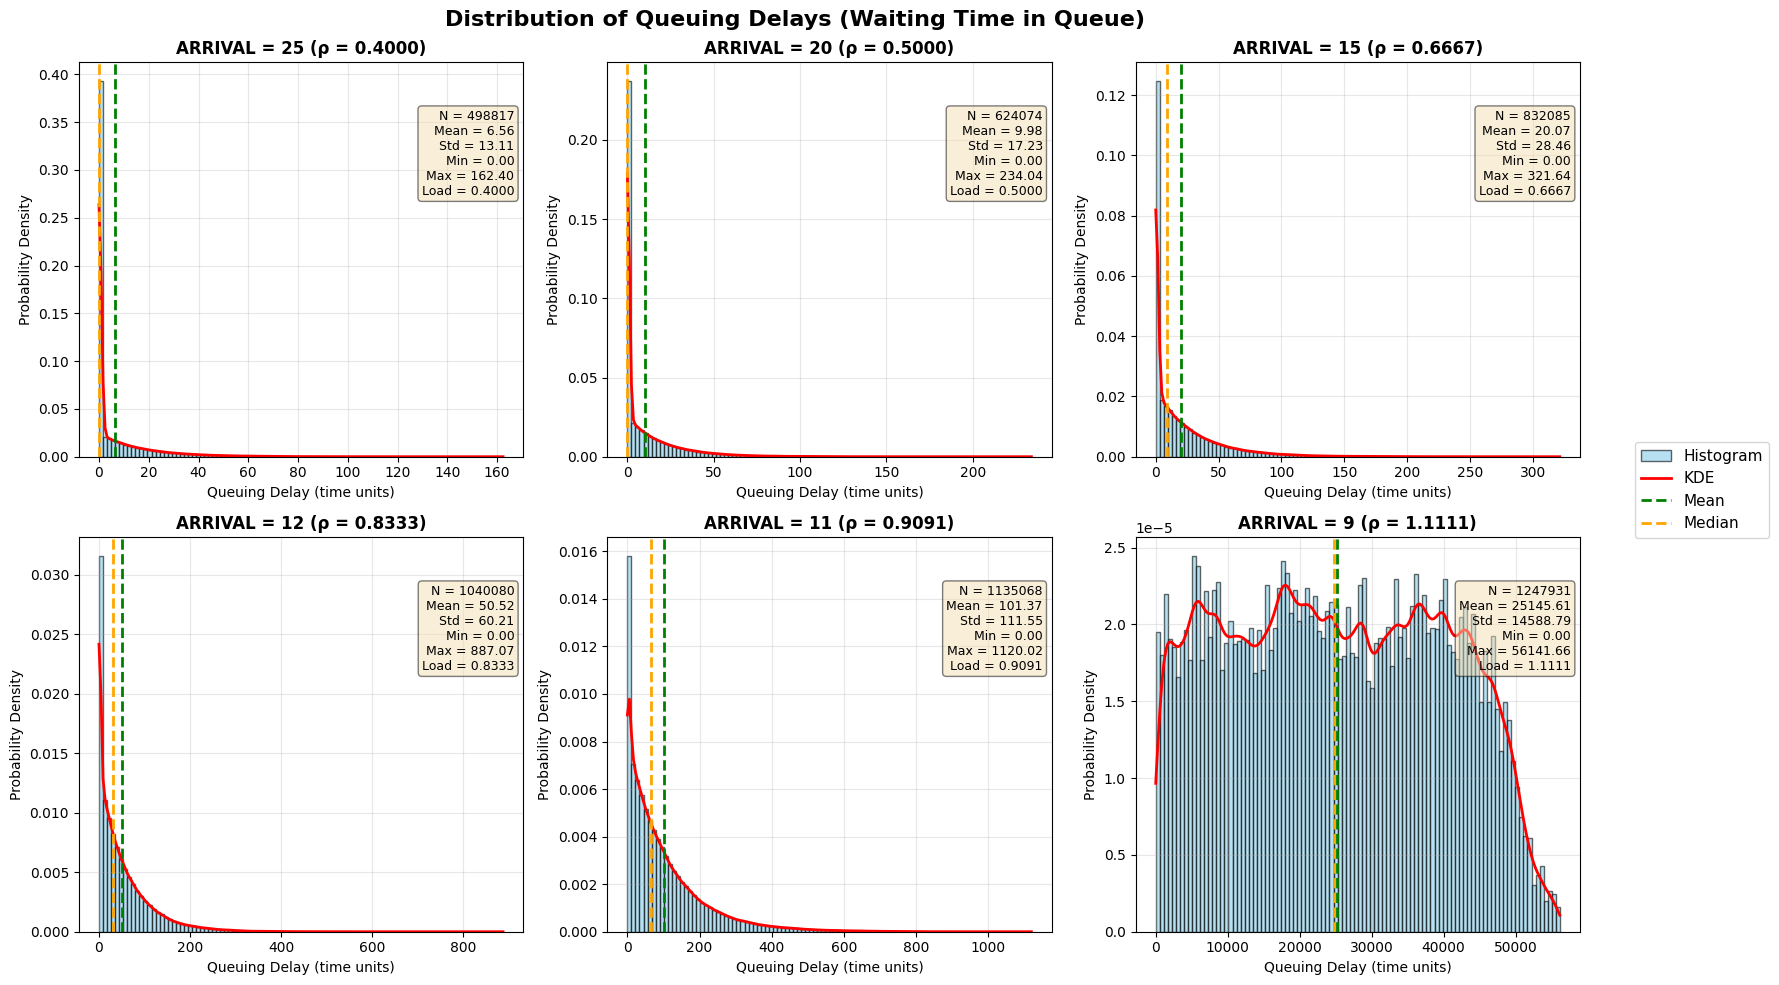

In [ ]:
# Plot distribution of queuing delays
plot_results(all_results, ARRIVALS, SERVICE)


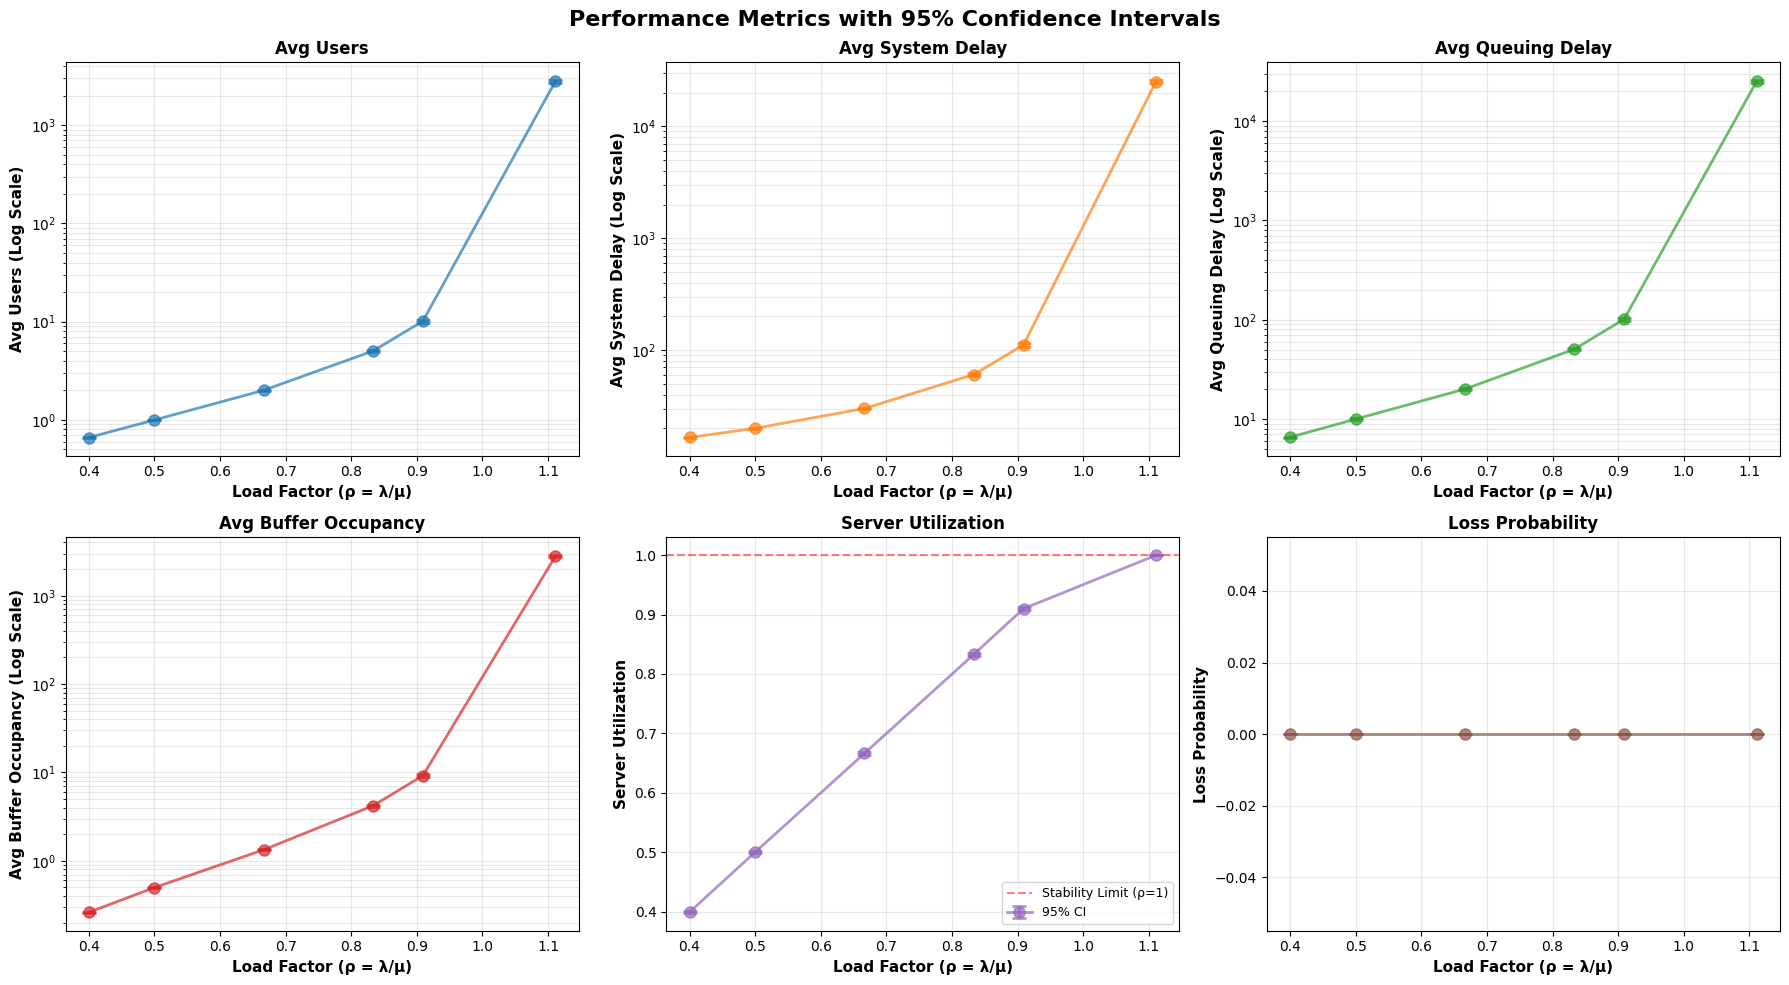


CONFIDENCE INTERVALS SUMMARY (95% Confidence Level)

Load Factor ρ = 0.4000 (Arrival = 25)
  avg_users                :       0.6610 [      0.6563,       0.6658]  Ratio:     0.0144
  avg_delay                :      16.5657 [     16.4394,      16.6921]  Ratio:     0.0153
  avg_waiting_delay        :       6.5581 [      6.4615,       6.6547]  Ratio:     0.0295
  avg_buffer_occupancy     :       0.2617 [      0.2580,       0.2654]  Ratio:     0.0285
  server_utilization       :       0.3993 [      0.3980,       0.4007]  Ratio:     0.0067
  loss_probability         :       0.0000 [      0.0000,       0.0000]  Ratio:        inf

Load Factor ρ = 0.5000 (Arrival = 20)
  avg_users                :       0.9986 [      0.9894,       1.0078]  Ratio:     0.0184
  avg_delay                :      20.0014 [     19.8208,      20.1820]  Ratio:     0.0181
  avg_waiting_delay        :       9.9838 [      9.8280,      10.1395]  Ratio:     0.0312
  avg_buffer_occupancy     :       0.4985 [      0.4906,   

In [ ]:
# Plot confidence intervals for all metrics
plot_confidence_intervals(all_results, ARRIVALS, SERVICE, confidence=0.95)


In [ ]:
# Compare M/M/1 vs M/M/2 performance
results_comparison_MMn, results_comparison_mm2 = comparison_report(SERVICE, ARRIVALS, BUFFER_SIZE, SIM_TIME, num_simulations=25)



COMPARISON REPORT: M/M/1 (1 Server) vs M/M/2 (2 Servers)

Running simulations with 1 server...
Running simulations with 2 servers...

RESULTS COMPARISON


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ARRIVAL RATE = 25 (Load Factor ρ = 0.4000)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Metric                              M/M/1 Mean      M/M/2 Mean      Difference (%)  M/M/1 Ratio     M/M/2 Ratio    
------------------------------------------------------------------------------------------------------------------------
Average Users in System             0.6610          0.4157          -37.11%         0.0144          0.0076         
Average System Delay (W)            16.5657         10.4183         -37.11%         0.0153          0.0064         
Average Queuing Delay (Wq)          6.5581          0.4098          -93.75%         0.0295

In [ ]:
# Print service rates and capacity analysis
print_service_rates_analysis(SERVICE, ARRIVALS)



SERVICE RATES AND SYSTEM CAPACITY ANALYSIS

SERVICE TIME (per customer): 10.0 time units
SERVICE RATE (μ, per server): 0.1000 customers/time unit
  → Each server can serve 1.0 customer per 10.0 time units

----------------------------------------------------------------------------------------------------------------------------------
Arrival (λ)     ρ M/M/1         System Status        ρ M/M/2         System Status             Capacity Gain       
----------------------------------------------------------------------------------------------------------------------------------
25.0            0.4000          STABLE (ρ<1)         0.2000          STABLE (ρ<1)              +100.0%
20.0            0.5000          STABLE (ρ<1)         0.2500          STABLE (ρ<1)              +100.0%
15.0            0.6667          STABLE (ρ<1)         0.3333          STABLE (ρ<1)              +100.0%
12.0            0.8333          STABLE (ρ<1)         0.4167          STABLE (ρ<1)              +100.0%
11.

In [ ]:
# Extract key metrics: show improvement percentage for M/M/2 vs M/M/1
print("\n" + "="*80)
print("KEY INSIGHT: Improvement of M/M/2 vs M/M/1 for each load scenario")
print("="*80 + "\n")

metrics_key = 'avg_delay'  # System delay

for arr in ARRIVALS:
    rho_MMn = SERVICE / arr
    data_MMn = results_comparison_MMn[arr][metrics_key]
    data_mm2 = results_comparison_mm2[arr][metrics_key]
    
    mean_MMn = np.mean(data_MMn)
    mean_mm2 = np.mean(data_mm2)
    pct_improvement = ((mean_MMn - mean_mm2) / mean_MMn) * 100
    
    absolute_reduction = mean_MMn - mean_mm2
    
    print(f"ρ = {rho_MMn:.4f} (ARRIVAL={arr})")
    print(f"  M/M/1 avg delay: {mean_MMn:12.2f}")
    print(f"  M/M/2 avg delay: {mean_mm2:12.2f}")
    print(f"  Absolute reduction: {absolute_reduction:12.2f} time units")
    print(f"  Percentage improvement: {pct_improvement:6.2f}%")
    print()


KEY INSIGHT: Improvement of M/M/2 vs M/M/1 for each load scenario

ρ = 0.4000 (ARRIVAL=25)
  M/M/1 avg delay:        16.57
  M/M/2 avg delay:        10.42
  Absolute reduction:         6.15 time units
  Percentage improvement:  37.11%

ρ = 0.5000 (ARRIVAL=20)
  M/M/1 avg delay:        20.00
  M/M/2 avg delay:        10.68
  Absolute reduction:         9.32 time units
  Percentage improvement:  46.60%

ρ = 0.6667 (ARRIVAL=15)
  M/M/1 avg delay:        30.08
  M/M/2 avg delay:        11.26
  Absolute reduction:        18.82 time units
  Percentage improvement:  62.56%

ρ = 0.8333 (ARRIVAL=12)
  M/M/1 avg delay:        60.52
  M/M/2 avg delay:        12.12
  Absolute reduction:        48.40 time units
  Percentage improvement:  79.97%

ρ = 0.9091 (ARRIVAL=11)
  M/M/1 avg delay:       111.37
  M/M/2 avg delay:        12.62
  Absolute reduction:        98.75 time units
  Percentage improvement:  88.67%

ρ = 1.1111 (ARRIVAL=9)
  M/M/1 avg delay:     25160.92
  M/M/2 avg delay:        14.45



BUFFER SIZE IMPACT ANALYSIS (Servers: 2, Arrival: 4.5, Service: 10.0)

Simulating Buffer Size: 1...
Simulating Buffer Size: 2...
Simulating Buffer Size: 3...
Simulating Buffer Size: 5...
Simulating Buffer Size: 10...
Simulating Buffer Size: 20...
Simulating Buffer Size: 50...
Simulating Buffer Size: 100...
Simulating Buffer Size: Infinite...


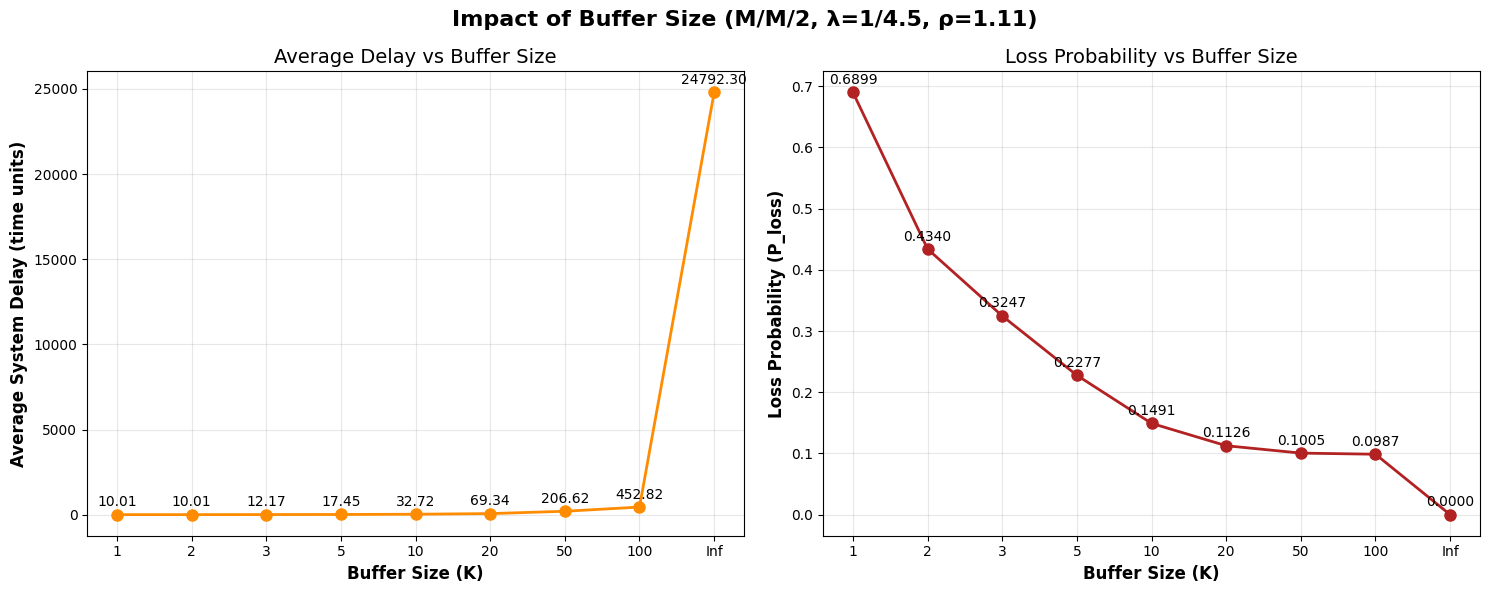


Buffer Size     | Avg Delay (W)             | Loss Prob (Ploss)   
-----------------------------------------------------------------
1               | 10.0148                   | 0.689882            
2               | 10.0124                   | 0.433995            
3               | 12.1660                   | 0.324656            
5               | 17.4482                   | 0.227662            
10              | 32.7162                   | 0.149127            
20              | 69.3439                   | 0.112582            
50              | 206.6178                  | 0.100504            
100             | 452.8185                  | 0.098680            
Infinite        | 24792.2994                | 0.000000            




In [ ]:
# =========================================================================
# Esegui l'analisi del buffer 
# (impostiamo come test un M/M/2 instabile con: interarrivo = 4.5, rho=1.11)
# Raddoppiando i server da 1 a 2, dimezziamo il tempo di interarrivo (raddoppiamo il rate) 
# per mantenere la stessa instabilità.
# =========================================================================

test_arrival = 4.5
test_buffer_sizes = [1, 2, 3, 5, 10, 20, 50, 100, float('inf')]

buffer_results = analyze_buffer_impact(service_time=SERVICE, 
                                       arrival_rate=test_arrival, 
                                       num_servers=2, 
                                       buffer_sizes=test_buffer_sizes, 
                                       sim_time=SIM_TIME, 
                                       num_simulations=25)

plot_buffer_impact(buffer_results, test_buffer_sizes, test_arrival, num_servers=2, service_time=SERVICE)



BUFFER SIZE IMPACT ANALYSIS (Servers: 1, Arrival: 9, Service: 10.0)

Simulating Buffer Size: 1...
Simulating Buffer Size: 2...
Simulating Buffer Size: 3...
Simulating Buffer Size: 5...
Simulating Buffer Size: 10...
Simulating Buffer Size: 20...
Simulating Buffer Size: 50...
Simulating Buffer Size: 100...
Simulating Buffer Size: Infinite...


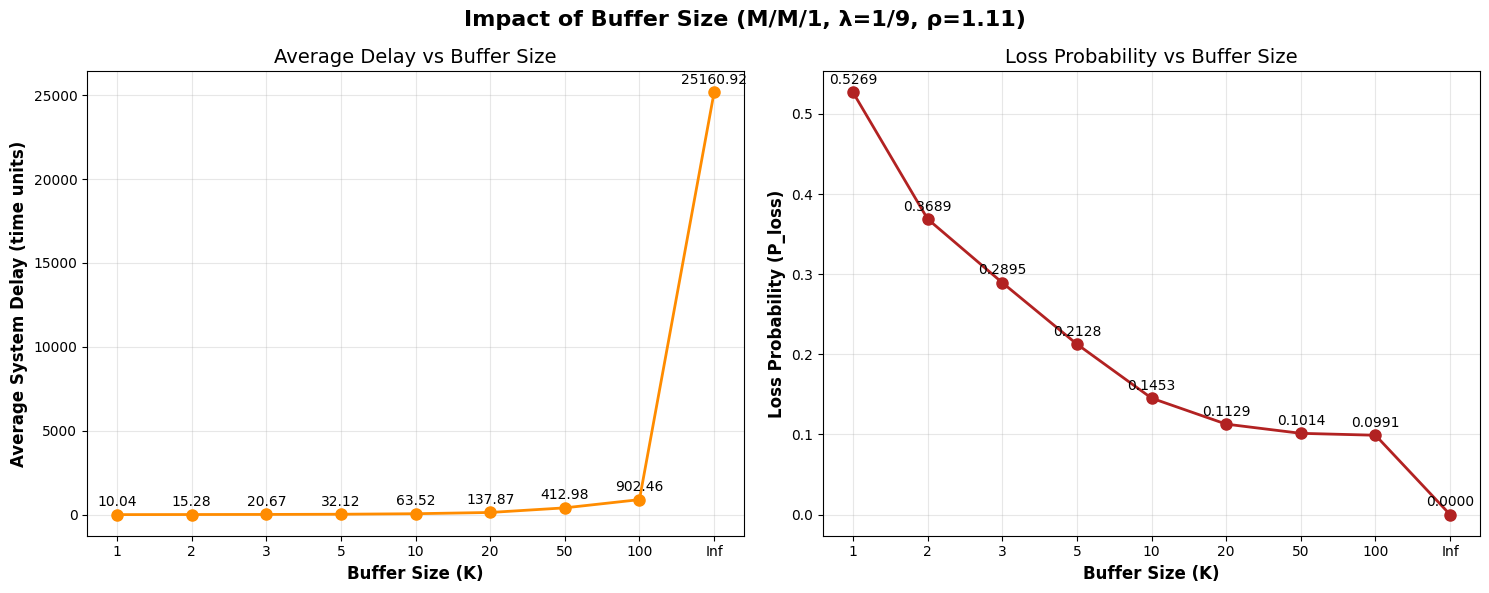


Buffer Size     | Avg Delay (W)             | Loss Prob (Ploss)   
-----------------------------------------------------------------
1               | 10.0378                   | 0.526868            
2               | 15.2821                   | 0.368856            
3               | 20.6729                   | 0.289451            
5               | 32.1211                   | 0.212774            
10              | 63.5190                   | 0.145341            
20              | 137.8685                  | 0.112921            
50              | 412.9815                  | 0.101443            
100             | 902.4565                  | 0.099053            
Infinite        | 25160.9181                | 0.000000            




In [ ]:
# =========================================================================
# Esegui l'analisi del buffer 
# (impostiamo come test un M/M/1 instabile con: ARRIVAL = 9, rho=1.11)
# InQuesto test satureremo il sistema per vedere un trade-off netto tra Delay e Probabilità di perdita
# =========================================================================

test_arrival = 9
test_buffer_sizes = [1, 2, 3, 5, 10, 20, 50, 100, float('inf')]

buffer_results = analyze_buffer_impact(service_time=SERVICE, 
                                       arrival_rate=test_arrival, 
                                       num_servers=1, 
                                       buffer_sizes=test_buffer_sizes, 
                                       sim_time=SIM_TIME, 
                                       num_simulations=25)

plot_buffer_impact(buffer_results, test_buffer_sizes, test_arrival, num_servers=1, service_time=SERVICE)


Comparing Shared vs Separate Buffers (Servers=2, Arrival=4.5)

Evaluating Shared Buffer (M/M/N/K)...

BUFFER SIZE IMPACT ANALYSIS (Servers: 2, Arrival: 4.5, Service: 10.0)

Simulating Buffer Size: 2...
Simulating Buffer Size: 4...
Simulating Buffer Size: 10...
Simulating Buffer Size: 20...
Simulating Buffer Size: Infinite...

Evaluating Separate Buffers (JSQ Routing)...
Simulating Separate Buffers (Total Capacity: 2)...
Simulating Separate Buffers (Total Capacity: 4)...
Simulating Separate Buffers (Total Capacity: 10)...
Simulating Separate Buffers (Total Capacity: 20)...
Simulating Separate Buffers (Total Capacity: Inf)...


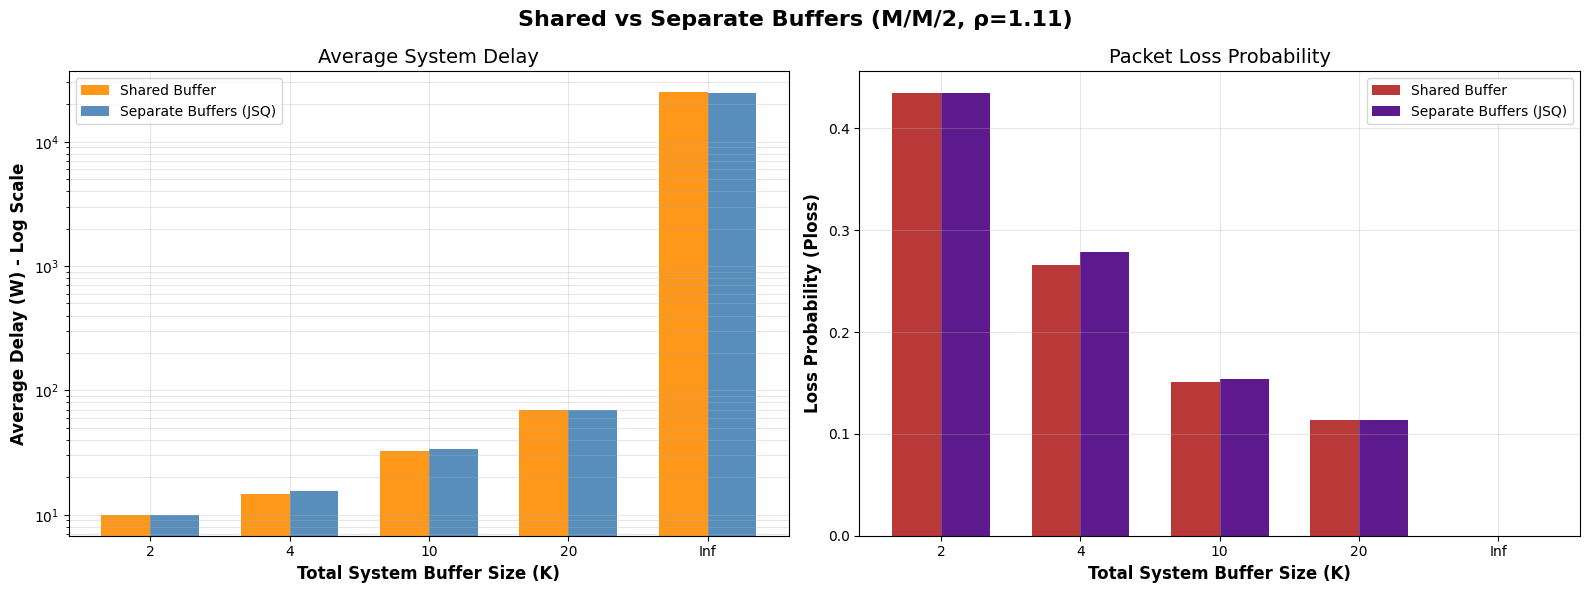


------------------------------------------------------------------------------------------
Buffer(K)    | Delay (Shared)     | Delay (Sep)        | Loss (Shared)      | Loss (Sep)        
------------------------------------------------------------------------------------------
2            | 10.0218            | 10.0218            | 0.4343             | 0.4343            
4            | 14.7360            | 15.5597            | 0.2655             | 0.2791            
10           | 32.8248            | 33.7451            | 0.1505             | 0.1538            
20           | 69.3878            | 69.8218            | 0.1137             | 0.1133            
Inf          | 24910.6056         | 24704.7431         | 0.0000             | 0.0000            




In [ ]:
# ---- RUN THE COMPARISON AUTOMATICALLY ----
# Testeremo un M/M/2 con parametri di carico instabile (così da stressare i buffer limitati)
test_arr_policy = 4.5  
test_buffers_policy = [2, 4, 10, 20, float('inf')]

# Run the comparative analysis
compare_shared_vs_separate_buffers(service_time=SERVICE, 
                                   arrival_rate=test_arr_policy, 
                                   num_servers=2, 
                                   buffer_sizes=test_buffers_policy, 
                                   sim_time=SIM_TIME, 
                                   num_simulations=10)


Comparing Shared vs Separate Buffers (Servers=2, Arrival=9)

Evaluating Shared Buffer (M/M/N/K)...

BUFFER SIZE IMPACT ANALYSIS (Servers: 2, Arrival: 9, Service: 10.0)

Simulating Buffer Size: 2...
Simulating Buffer Size: 4...
Simulating Buffer Size: 10...
Simulating Buffer Size: 20...
Simulating Buffer Size: Infinite...

Evaluating Separate Buffers (JSQ Routing)...
Simulating Separate Buffers (Total Capacity: 2)...
Simulating Separate Buffers (Total Capacity: 4)...
Simulating Separate Buffers (Total Capacity: 10)...
Simulating Separate Buffers (Total Capacity: 20)...
Simulating Separate Buffers (Total Capacity: Inf)...


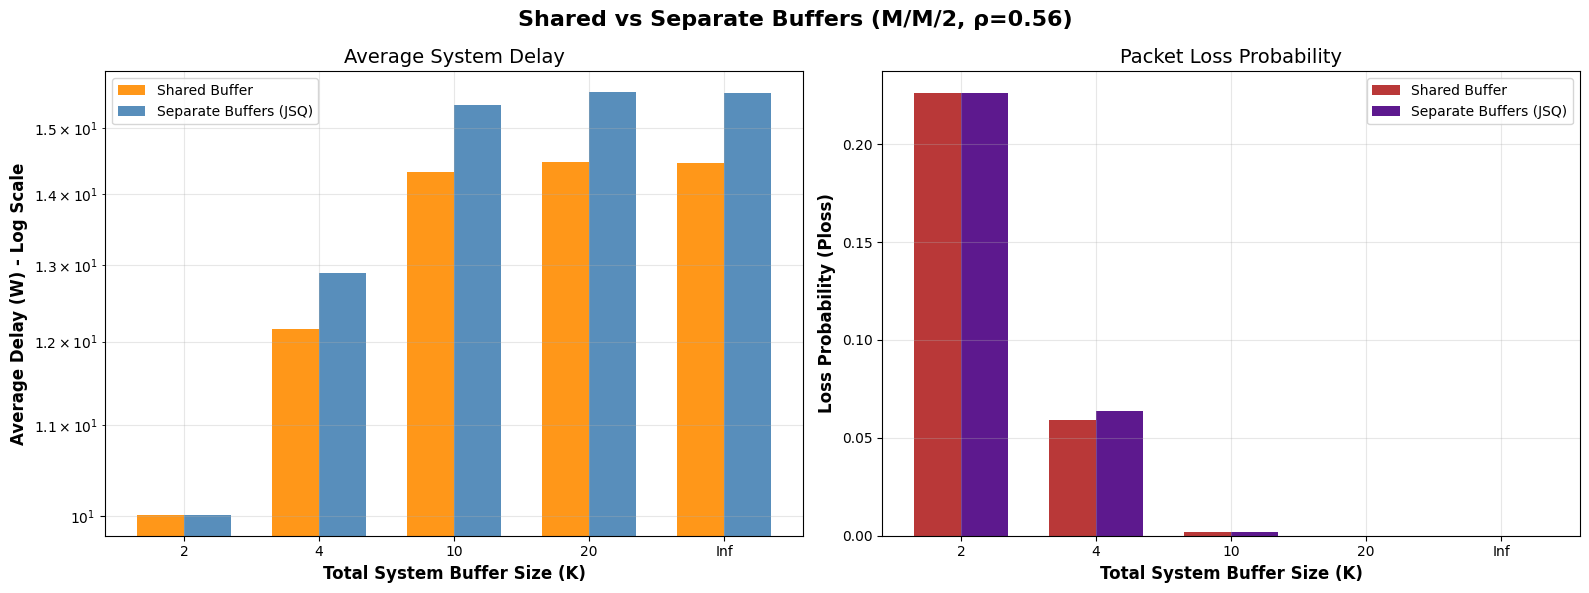


------------------------------------------------------------------------------------------
Buffer(K)    | Delay (Shared)     | Delay (Sep)        | Loss (Shared)      | Loss (Sep)        
------------------------------------------------------------------------------------------
2            | 10.0153            | 10.0153            | 0.2259             | 0.2259            
4            | 12.1638            | 12.8896            | 0.0593             | 0.0639            
10           | 14.3270            | 15.3761            | 0.0017             | 0.0018            
20           | 14.4726            | 15.5723            | 0.0000             | 0.0000            
Inf          | 14.4707            | 15.5587            | 0.0000             | 0.0000            




In [ ]:
# ---- RUN THE COMPARISON AUTOMATICALLY ----
# Testeremo un M/M/2 con parametri di carico stabile (così da stressare i buffer limitati)
test_arr_policy = 9 
test_buffers_policy = [2, 4, 10, 20, float('inf')]

# Run the comparative analysis
compare_shared_vs_separate_buffers(service_time=SERVICE, 
                                   arrival_rate=test_arr_policy, 
                                   num_servers=2, 
                                   buffer_sizes=test_buffers_policy, 
                                   sim_time=SIM_TIME, 
                                   num_simulations=10)


Running policy: random...

LOAD DISTRIBUTION SUMMARY - random
Simulations: 10, Servers: 3

Per-server utilization (busy_time / sim_time):
  Server 0: mean=0.2768  std=0.0067
  Server 1: mean=0.2784  std=0.0089
  Server 2: mean=0.2800  std=0.0072

Per-server completed jobs (#served):
  Server 0: mean=1374.2  std=31.9
  Server 1: mean=1381.4  std=21.4
  Server 2: mean=1394.2  std=15.3


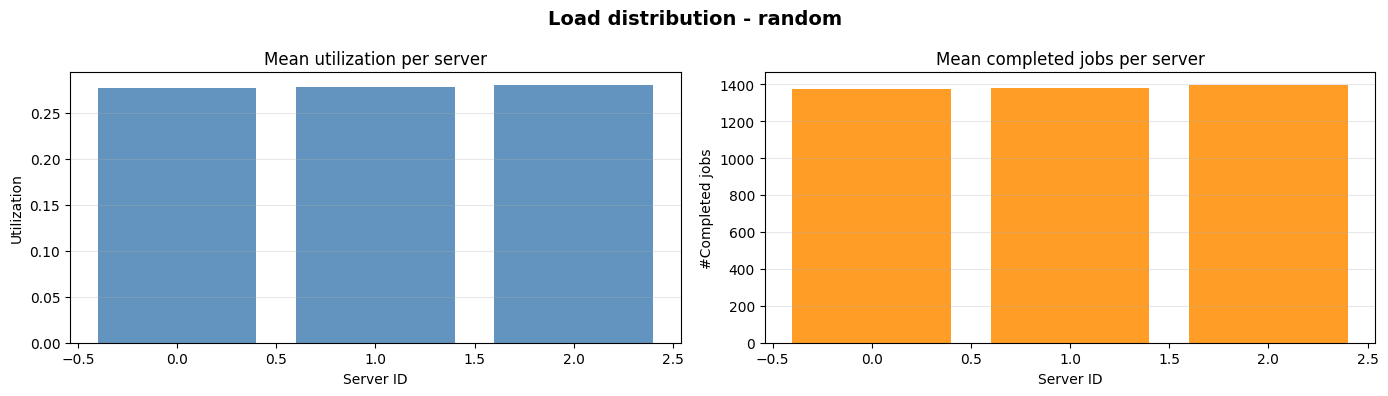


Running policy: round_robin...

LOAD DISTRIBUTION SUMMARY - round_robin
Simulations: 10, Servers: 3

Per-server utilization (busy_time / sim_time):
  Server 0: mean=0.2816  std=0.0083
  Server 1: mean=0.2785  std=0.0101
  Server 2: mean=0.2794  std=0.0079

Per-server completed jobs (#served):
  Server 0: mean=1383.5  std=28.6
  Server 1: mean=1395.7  std=22.0
  Server 2: mean=1387.5  std=27.6


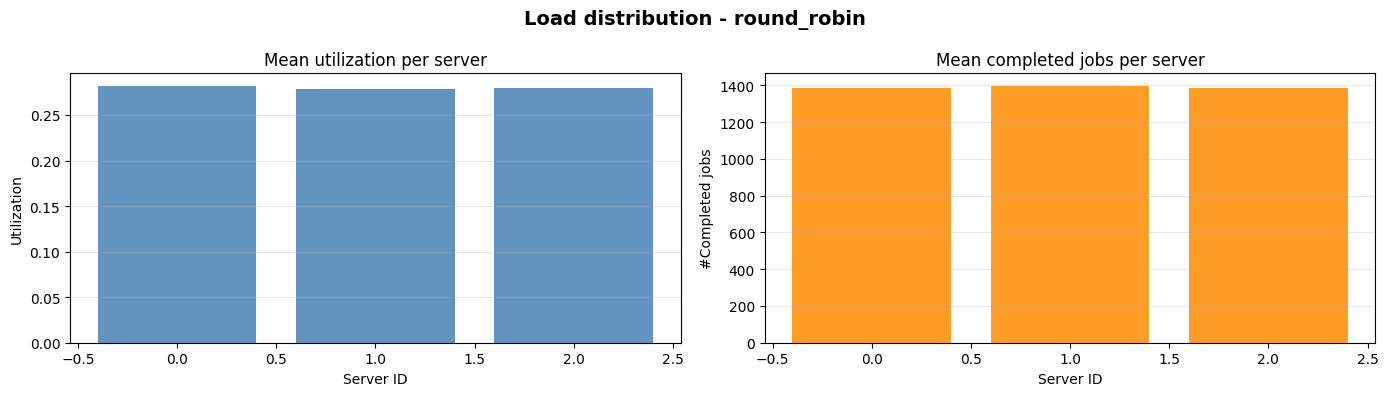


----------------------------------------------------------------------------------------------------
GLOBAL PERFORMANCE COMPARISON (arrival=12, servers=3, buffer=inf)
----------------------------------------------------------------------------------------------------
Policy       | AvgDelay(W)    | AvgWq          | Ploss        | Util(total) 
----------------------------------------------------------------------------------------------------
random       | 10.6573        | 0.5902         | 0.000000     | 0.8353      
round_robin  | 10.6179        | 0.5433         | 0.000000     | 0.8396      
----------------------------------------------------------------------------------------------------



In [ ]:
# =====================================================================
# DEMO (Routing policies): Random vs Round Robin (multi-server)
# NOTE: keep sim time modest for quick runs; increase for final report.
# =====================================================================

demo_num_servers = 3
demo_arrival = 12          # inter-arrival time
demo_buffer = float('inf') # or e.g. 30 for finite buffer
demo_sim_time = 50000      # quick sanity; use SIM_TIME for final
demo_sims = 10

_ = compare_policies(service_time=SERVICE,
                    arrival_scenario=demo_arrival,
                    num_servers=demo_num_servers,
                    buffer_size=demo_buffer,
                    sim_time=demo_sim_time,
                    policies=("random", "round_robin"),
                    num_simulations=demo_sims)


Running policy: random...

LOAD DISTRIBUTION SUMMARY - random
Simulations: 10, Servers: 3
Service rates μ per server (and mean service time 1/μ):
  Server 0: μ=0.1250  (E[S]=8.00)
  Server 1: μ=0.1000  (E[S]=10.00)
  Server 2: μ=0.0667  (E[S]=15.00)

Per-server utilization (busy_time / sim_time):
  Server 0: mean=0.2449  std=0.0073
  Server 1: mean=0.2819  std=0.0110
  Server 2: mean=0.3649  std=0.0093

Per-server completed jobs (#served):
  Server 0: mean=1514.3  std=37.4
  Server 1: mean=1405.8  std=29.4
  Server 2: mean=1221.6  std=20.1


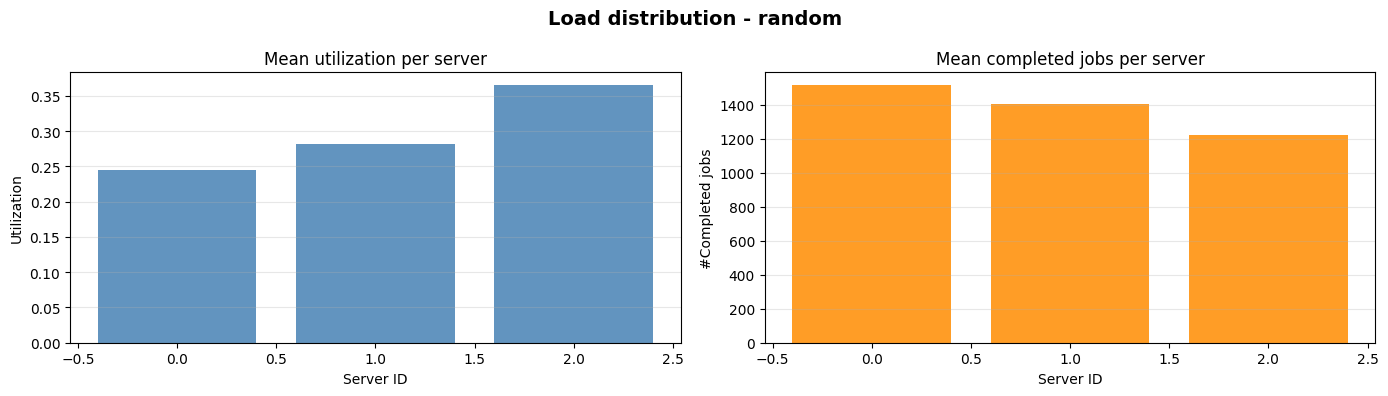


Running policy: round_robin...

LOAD DISTRIBUTION SUMMARY - round_robin
Simulations: 10, Servers: 3
Service rates μ per server (and mean service time 1/μ):
  Server 0: μ=0.1250  (E[S]=8.00)
  Server 1: μ=0.1000  (E[S]=10.00)
  Server 2: μ=0.0667  (E[S]=15.00)

Per-server utilization (busy_time / sim_time):
  Server 0: mean=0.2357  std=0.0078
  Server 1: mean=0.2878  std=0.0099
  Server 2: mean=0.3822  std=0.0098

Per-server completed jobs (#served):
  Server 0: mean=1466.9  std=28.9
  Server 1: mean=1416.0  std=28.4
  Server 2: mean=1277.5  std=25.9


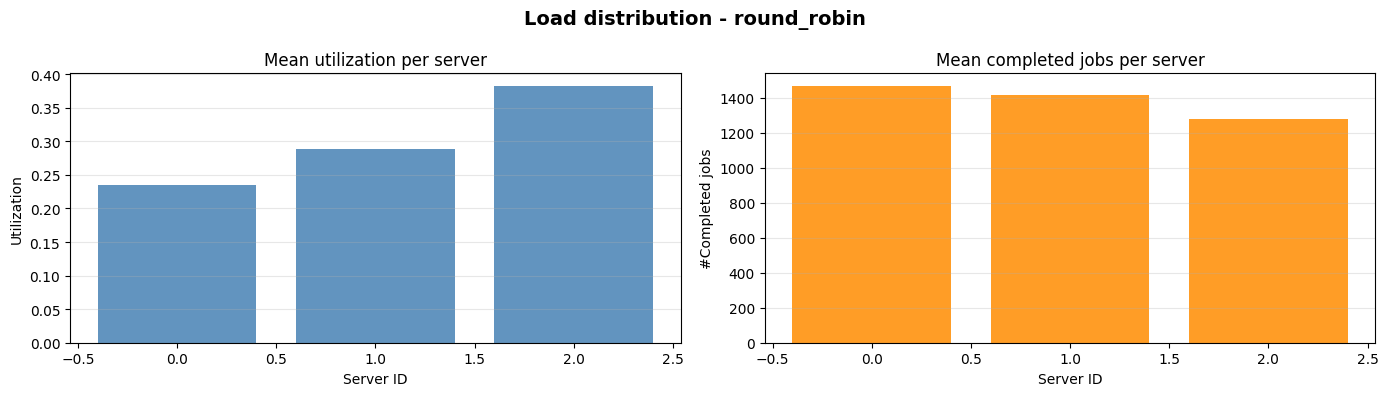


Running policy: rate_biased...

LOAD DISTRIBUTION SUMMARY - rate_biased
Simulations: 10, Servers: 3
Service rates μ per server (and mean service time 1/μ):
  Server 0: μ=0.1250  (E[S]=8.00)
  Server 1: μ=0.1000  (E[S]=10.00)
  Server 2: μ=0.0667  (E[S]=15.00)

Per-server utilization (busy_time / sim_time):
  Server 0: mean=0.3020  std=0.0055
  Server 1: mean=0.2906  std=0.0058
  Server 2: mean=0.2565  std=0.0134

Per-server completed jobs (#served):
  Server 0: mean=1874.9  std=32.0
  Server 1: mean=1440.2  std=31.6
  Server 2: mean=850.4  std=31.5


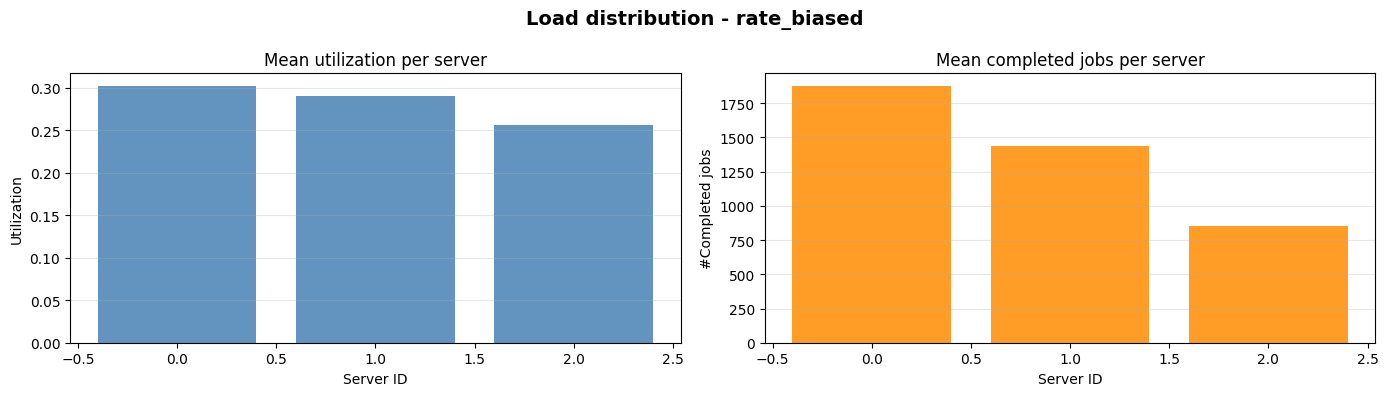


--------------------------------------------------------------------------------------------------------------
GLOBAL PERFORMANCE COMPARISON (arrival=12, servers=3, buffer=inf, bias_alpha=2.0)
--------------------------------------------------------------------------------------------------------------
Policy       | AvgDelay(W)    | AvgWq          | Ploss        | Util(total) 
--------------------------------------------------------------------------------------------------------------
random       | 11.4917        | 0.7227         | 0.000000     | 0.8918      
round_robin  | 11.5766        | 0.6923         | 0.000000     | 0.9059      
rate_biased  | 10.7999        | 0.6065         | 0.000000     | 0.8492      
--------------------------------------------------------------------------------------------------------------



In [31]:
# =====================================================================
# DEMO (Heterogeneous servers): different μ per server
# Policies: random vs round_robin vs rate_biased (prefers faster servers)
# =====================================================================

hetero_num_servers = 3
hetero_arrival = 12
hetero_buffer = float('inf')
hetero_sim_time = 50000
hetero_sims = 10

# Example: server 0 fastest, server 2 slowest
# μ = service rate (customers/time unit). Mean service time is E[S] = 1/μ
hetero_service_rates = [1/8, 1/10, 1/15]  # E[S]=8,10,15

_ = compare_policies(service_time=SERVICE,
                    arrival_scenario=hetero_arrival,
                    num_servers=hetero_num_servers,
                    buffer_size=hetero_buffer,
                    sim_time=hetero_sim_time,
                    policies=("random", "round_robin", "rate_biased"),
                    num_simulations=hetero_sims,
                    service_rates=hetero_service_rates,
                    bias_alpha=2.0)

## M/G/1: different service-time distributions
In this section we keep the *same* mean service time $E[S]$ and change only the distribution of $S$ (variance/SCV), to observe how performance changes (AvgDelay $W$, Avg queueing delay $W_q$, utilization, etc.).

Parameters: inter-arrival=12, E[S]=10.0, sims=10, sim_time=200000

M/G/1 – Service-time distribution sensitivity (same mean service time)
Distribution                    SCV(S)        E[S]           W          Wq    Util    Ploss
------------------------------------------------------------------------------------------------------------------------
Deterministic                    0.000      10.000      34.817      24.817   0.831  0.00000
Uniform ±50%                     0.085       9.959      36.285      26.274   0.832  0.00000
Erlang k=2                       0.508       9.967      46.811      36.789   0.832  0.00000
Exponential (M/M/1)              1.034       9.935      62.845      52.802   0.836  0.00000
Lognormal σ=1.0                  1.888       9.990      76.064      66.007   0.835  0.00000
Hyperexp p=0.5 fast_factor=5     2.350      10.002      87.806      77.779   0.830  0.00000



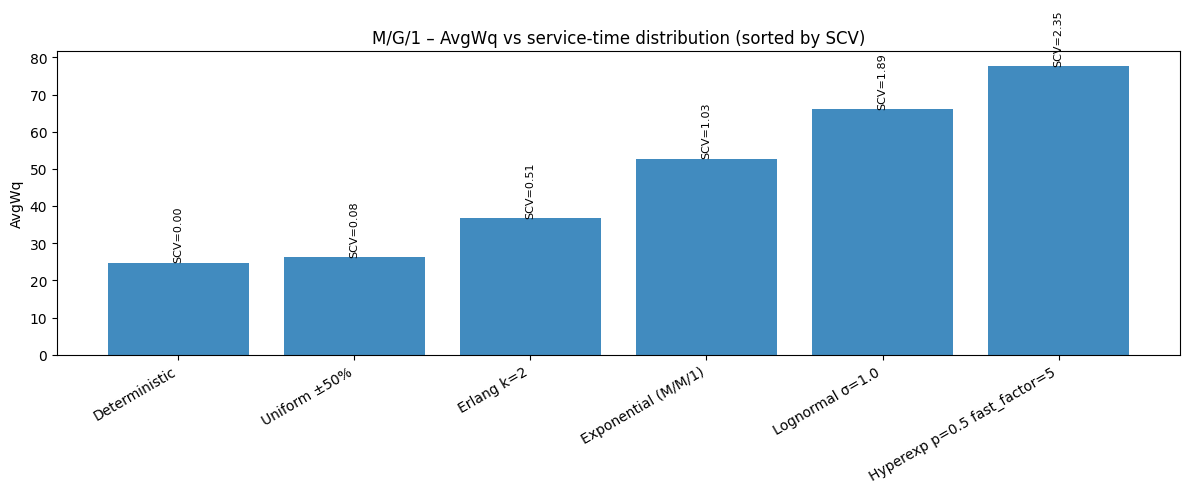

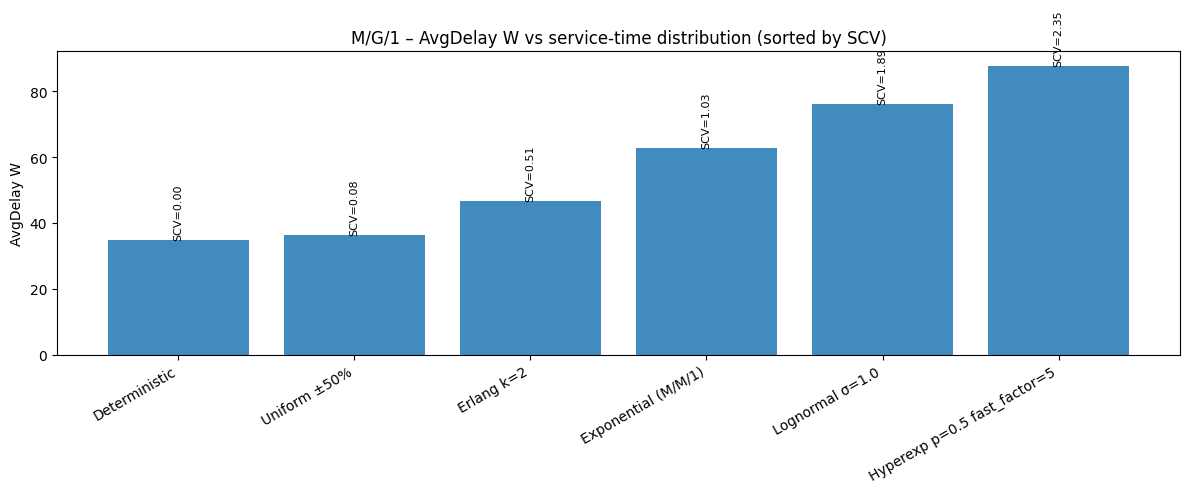

In [38]:
def compare_service_time_distributions_mg1(
    arrival_time,
    mean_service_time,
    buffer_size=float('inf'),
    sim_time=200000,
    num_simulations=10,
    sample_size=20000,
    dist_specs=None,
    seed_for_stats=12345,
    ):
    """Run M/G/1 simulations for multiple service-time distributions (same mean) and compare metrics."""
    if dist_specs is None:
        dist_specs = [
            ("Exponential (M/M/1)", "exponential", {}),
            ("Deterministic", "deterministic", {}),
            ("Erlang k=2", "erlang", {"k": 2}),
            ("Uniform ±50%", "uniform", {"spread": 0.5}),
            ("Lognormal σ=1.0", "lognormal", {"sigma": 1.0}),
            ("Hyperexp p=0.5 fast_factor=5", "hyperexponential", {"p": 0.5, "fast_factor": 5.0}),
        ]
    
    rows = []
    for label, dist, params in dist_specs:
        # Empirical variability summary (independent RNG)
        stats = summarize_service_distribution(
            mean_service_time, dist=dist, sample_size=sample_size, seed=seed_for_stats, **params
        )
        
        # Simulation (M/G/1 via get_results + service_dist)
        all_res = get_results(
            service_time=mean_service_time,
            arrivals=[arrival_time],
            num_servers=1,
            buffer_size=buffer_size,
            sim_time=sim_time,
            num_simulations=num_simulations,
            service_dist=dist,
            service_params=params,
        )
        r = all_res[arrival_time]
        
        rows.append({
            "Distribution": label,
            "SCV(S)": stats["scv"],
            "E[S] sample": stats["mean"],
            "AvgDelay W": float(np.mean(r["avg_delay"])),
            "AvgWq": float(np.mean(r["avg_waiting_delay"])),
            "AvgUsers": float(np.mean(r["avg_users"])),
            "Util": float(np.mean(r["server_utilization"])),
            "Ploss": float(np.mean(r["loss_probability"])),
        })
    
    # Sort by variability (low -> high) to make the trend clearer
    rows.sort(key=lambda d: d["SCV(S)"])
    return rows


def print_mg1_distribution_comparison(rows, title=None):
    if title:
        print(title)
    headers = ["Distribution", "SCV(S)", "E[S] sample", "AvgDelay W", "AvgWq", "Util", "Ploss"]
    col_widths = {h: max(len(h), *(len(str(r[h])) for r in rows)) for h in headers}
    col_widths["Distribution"] = max(col_widths["Distribution"], 28)
    
    def fmt_row(r):
        return (
            f"{r['Distribution']:<{col_widths['Distribution']}}  "
            f"{r['SCV(S)']:>8.3f}  "
            f"{r['E[S] sample']:>10.3f}  "
            f"{r['AvgDelay W']:>10.3f}  "
            f"{r['AvgWq']:>10.3f}  "
            f"{r['Util']:>6.3f}  "
            f"{r['Ploss']:>7.5f}"
        )
    
    print("\n" + "=" * 120)
    print("M/G/1 – Service-time distribution sensitivity (same mean service time)")
    print("=" * 120)
    print(f"{'Distribution':<{col_widths['Distribution']}}  {'SCV(S)':>8}  {'E[S]':>10}  {'W':>10}  {'Wq':>10}  {'Util':>6}  {'Ploss':>7}")
    print("-" * 120)
    for r in rows:
        print(fmt_row(r))
    print("=" * 120 + "\n")


def plot_mg1_distribution_comparison(rows, metric_key="AvgWq"):
    labels = [r["Distribution"] for r in rows]
    values = [r[metric_key] for r in rows]
    scvs = [r["SCV(S)"] for r in rows]
    x = np.arange(len(labels))
    plt.figure(figsize=(12, 5))
    bars = plt.bar(x, values, color="#1f77b4", alpha=0.85)
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel(metric_key)
    plt.title(f"M/G/1 – {metric_key} vs service-time distribution (sorted by SCV)")
    for i, (bar, scv) in enumerate(zip(bars, scvs)):
        height = bar.get_height()
        plt.text(i, height, f"SCV={scv:.2f}", ha="center", va="bottom", fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()


# --- Example run (edit parameters as needed) ---
mg1_arrival_time = 12              # mean inter-arrival time
mg1_mean_service_time = SERVICE    # target E[S]
mg1_sim_time = 200000
mg1_num_simulations = 10
mg1_buffer_size = float('inf')

mg1_rows = compare_service_time_distributions_mg1(
    arrival_time=mg1_arrival_time,
    mean_service_time=mg1_mean_service_time,
    buffer_size=mg1_buffer_size,
    sim_time=mg1_sim_time,
    num_simulations=mg1_num_simulations,
)

print_mg1_distribution_comparison(
    mg1_rows,
    title=f"Parameters: inter-arrival={mg1_arrival_time}, E[S]={mg1_mean_service_time}, sims={mg1_num_simulations}, sim_time={mg1_sim_time}"
)

plot_mg1_distribution_comparison(mg1_rows, metric_key="AvgWq")
plot_mg1_distribution_comparison(mg1_rows, metric_key="AvgDelay W")